# Shapley Methods — Results Analysis

Reusable analysis notebook. Change `DATASET` in the **Configuration** cell and re-run all cells to analyse any experiment run.

Sections:
1. Configuration & Imports
2. Pipeline Timing Summary
3. Load Shapley Values
4. Global Feature Importance Comparison
5. Instance-Level Configuration
6. Causal Graph Structure: PC vs LiNGAM
   - 6.1. True Causal Graph
7. DAG Node Highlight: PC vs LiNGAM
   - 7.1. SHAP Attribution Comparison: PC vs LiNGAM
8. True DAG Node Highlight
9. Graph Sensitivity Analysis
   - 9.1. Load SHAP Values (All Methods × Graphs)
   - 9.2. Graph Sensitivity Score (GSS)
   - 9.3. Ranking Robustness & True-Parent Recovery
   - 9.4. Sign Stability Score (SSS)
   - 9.5. Method Recommendation Summary
10. True-Graph Alignment (TGA)
    - 10.1. Sign Alignment vs True Graph
    - 10.2. Magnitude True-Graph Alignment
11. Feature Importance Export
12. Adjacency Matrix Comparison

## 1. Configuration & Imports

In [1]:
import sys
from pathlib import Path as _Path
sys.path.insert(0, str(_Path("..").resolve()))

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import json, re
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

import importlib
import analysis_utils
importlib.reload(analysis_utils)

from analysis_utils import (
    resolve_features,
    mean_abs_shap, top_k_jaccard,
    compute_sign_agreement, compute_sign_alignment, compute_tga,
    compute_sss, compute_gss,
    edge_recovery, flow_graph_stats, parse_pipeline_timing,
    build_dag_graph, make_dag_pos, draw_dag, draw_dag_highlight, PROX_PALETTE,
    make_shap_scatter_figure, make_instance_shap_figure,
    plot_shap_scatter_pc_vs_lingam, plot_instance_shap_pc_vs_lingam,
    # ── stand-alone plot functions ──────────────────────────────────────────
    plot_timing_table,
    plot_feature_importance_bar,
    plot_dag_comparison,
    plot_true_dag,
    plot_dag_highlight,
    plot_dag_highlight_true,
    plot_gss_heatmap,
    plot_gss_delta_box,
    plot_spearman_heatmap,
    plot_jaccard_bar,
    plot_parent_precision_bar,
    plot_sss_heatmap,
    plot_sss_bar,
    plot_sign_alignment_heatmap,
    plot_sign_alignment_bar,
    plot_tga_heatmap,
    plot_tga_bar,
    plot_summary_table,
    plot_adjacency_comparison,
)

In [2]:
# ── Change these two lines to re-run analysis on any dataset ───────────
DATASET        = "linear_no_conf_f50_s1000_p30"
# DATASET        = "mixed_no_conf_f50_s1000_p50"
MODEL          = "lgbm"

# Number of top features (ranked by Traditional Shapley) shown in
# the bar chart (Analysis 4) and scatter grid (Analyses 5 & 6).
N_TOP_FEATURES = 20

# ── Paths (notebook lives in notebooks/, project root is one level up) ──
BASE_DIR           = Path("..").resolve()
EXPLAINABILITY_DIR = BASE_DIR / "data" / "explainability"
CAUSAL_DIR         = BASE_DIR / "data" / "causal"
PROCESSED_DIR      = BASE_DIR / "data" / "processed"
SYNTHETIC_DIR      = BASE_DIR / "data" / "synthetic"
LOGS_DIR           = BASE_DIR / "logs"

# ── Plots output folder (one sub-folder per dataset inside notebooks/plots/) ──
PLOTS_DIR = Path("plots") / DATASET
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"Plots will be saved to: {PLOTS_DIR.resolve()}")

# ── Consistent colour scheme across all plots ───────────────────────────
METHOD_COLORS = {
    "Scratch":     "#636363",
    "Asymmetric":  "#2166ac",
    "Causal":      "#4dac26",
    "ShapleyFlow": "#d01c8b",
}

# ── Global method / graph lists used across sections 9–11 ───────────────
BASE_METHODS = ["Asymmetric", "Causal", "Flow"]
DISC_GRAPHS  = ["PC", "LiNGAM"]
K_VALUES     = [5, 10, 20]

print(f"Dataset : {DATASET}")
print(f"Model   : {MODEL}")
print(f"Top N   : {N_TOP_FEATURES}")
print(f"Synthetic dir exists: {SYNTHETIC_DIR.exists()}")

Plots will be saved to: /Users/juanrios/Documents/master_thesis/notebooks/plots/linear_no_conf_f50_s1000_p30
Dataset : linear_no_conf_f50_s1000_p30
Model   : lgbm
Top N   : 20
Synthetic dir exists: True


## 2. Pipeline Timing Summary

In [3]:
timing_df, total_time = parse_pipeline_timing(LOGS_DIR, DATASET)

if timing_df is not None:
    fig_timing = plot_timing_table(timing_df, total_time, DATASET, save_dir=PLOTS_DIR)
else:
    print("Could not parse timing log.")

Log file: pipeline_20260601_012626.log


  ✅  Saved → plots/linear_no_conf_f50_s1000_p30/timing_table_linear_no_conf_f50_s1000_p30.png


## 3. Load Shapley Values

In [4]:
exp_dir = EXPLAINABILITY_DIR / DATASET / MODEL

# ── Method registry ───────────────────────────────────────────────────────
# key  : display name used across all plots
# value: relative path inside exp_dir
METHOD_PATHS = {
    "Scratch":                exp_dir / "scratch"  / "shapley_values.npy",
    "Asymmetric (PC)":        exp_dir / "pc"       / "asymmetric" / "shapley_values.npy",
    "Causal (PC)":            exp_dir / "pc"       / "causal"     / "shapley_values.npy",
    "Flow (PC)":              exp_dir / "pc"       / "flow"       / "shapley_values.npy",
    "Asymmetric (LiNGAM)":   exp_dir / "lingam"   / "asymmetric" / "shapley_values.npy",
    "Causal (LiNGAM)":       exp_dir / "lingam"   / "causal"     / "shapley_values.npy",
    "Flow (LiNGAM)":         exp_dir / "lingam"   / "flow"       / "shapley_values.npy",
}

shap_data = {}
for name, path in METHOD_PATHS.items():
    if path.exists():
        sv = np.load(path)
        shap_data[name] = sv
        nan_pct = 100 * np.isnan(sv).mean()
        zero_pct = 100 * (sv == 0).mean()
        print(f"  {name:28s}  shape={sv.shape}  "
              f"mean|SHAP|={np.abs(sv).mean():.4f}  "
              f"NaN={nan_pct:.1f}%  zeros={zero_pct:.1f}%")
    else:
        print(f"  {name:28s}  NOT FOUND: {path}")

# ── Feature names (X only, no Y) ─────────────────────────────────────────
with open(CAUSAL_DIR / f"{DATASET}_pc_results.json") as f:
    pc_results = json.load(f)
with open(CAUSAL_DIR / f"{DATASET}_lingam_results.json") as f:
    lingam_results = json.load(f)

feature_names = [n for n in pc_results["feature_names"] if n != "Y"]
n_features    = len(feature_names)

# ── Test instances used for SHAP (first n_shap rows of test set) ──────────
n_shap   = shap_data["Scratch"].shape[0]
test_df  = pd.read_parquet(PROCESSED_DIR / f"{DATASET}_test.parquet")
x_test   = test_df[feature_names].iloc[:n_shap].values   # shape: (n_shap, n_features)

# ── Graph statistics ──────────────────────────────────────────────────────

pc_edges,     pc_sources     = flow_graph_stats(pc_results["adjacency_matrix"],     n_features)
lingam_edges, lingam_sources = flow_graph_stats(lingam_results["adjacency_matrix"], n_features)

print(f"\nFeatures : {n_features}    SHAP instances : {n_shap}")
print(f"PC graph     : {pc_edges} edges, {pc_sources} sources")
print(f"LiNGAM graph : {lingam_edges} edges, {lingam_sources} sources")

  Scratch                       shape=(100, 50)  mean|SHAP|=0.2431  NaN=0.0%  zeros=0.0%
  Asymmetric (PC)               shape=(100, 50)  mean|SHAP|=0.2438  NaN=0.0%  zeros=0.0%
  Causal (PC)                   shape=(100, 50)  mean|SHAP|=0.3870  NaN=0.0%  zeros=0.0%
  Flow (PC)                     shape=(100, 50)  mean|SHAP|=0.2948  NaN=0.0%  zeros=12.6%
  Asymmetric (LiNGAM)           shape=(100, 50)  mean|SHAP|=0.2444  NaN=0.0%  zeros=0.0%
  Causal (LiNGAM)               shape=(100, 50)  mean|SHAP|=0.3583  NaN=0.0%  zeros=0.0%
  Flow (LiNGAM)                 shape=(100, 50)  mean|SHAP|=0.2809  NaN=0.0%  zeros=12.6%

Features : 50    SHAP instances : 100
PC graph     : 95 edges, 18 sources
LiNGAM graph : 131 edges, 15 sources


## 4. Global Feature Importance Comparison

Mean absolute SHAP value per feature.  
**Left panel** — ShapleyFromScratch + PC-graph methods.  
**Right panel** — ShapleyFromScratch + LiNGAM-graph methods.  
Features are sorted (left → right) by ShapleyFromScratch importance.

In [5]:
# ── Mean absolute SHAP per feature ───────────────────────────────────────
mean_abs = {name: np.abs(sv).mean(axis=0) for name, sv in shap_data.items()}

# Top-N features ranked by Traditional Shapley (Scratch)
scratch_rank = np.argsort(mean_abs["Scratch"])[::-1][:N_TOP_FEATURES]
top_features = [feature_names[i] for i in scratch_rank]


def _resolve_features(features=None):
    """Thin wrapper — delegates to analysis_utils.resolve_features."""
    return resolve_features(feature_names, scratch_rank, top_features, features)

# ── Method lists (used by scatter / instance cells below) ─────────────────
PC_METHODS     = ["Scratch", "Asymmetric (PC)",     "Causal (PC)",     "Flow (PC)"]
LINGAM_METHODS = ["Scratch", "Asymmetric (LiNGAM)", "Causal (LiNGAM)", "Flow (LiNGAM)"]

# Default: top-N by Traditional Shapley
fig_imp = plot_feature_importance_bar(
    shap_data, feature_names, scratch_rank, top_features, mean_abs,
    pc_edges, pc_sources, lingam_edges, lingam_sources,
    METHOD_COLORS, DATASET, N_TOP_FEATURES,
    save_dir=PLOTS_DIR,
)

  ✅  Saved → plots/linear_no_conf_f50_s1000_p30/feature_importance_linear_no_conf_f50_s1000_p30.png


## 5. Instance-Level Configuration

Select a fixed set of test instances for per-instance SHAP visualisations (Sections 7 and 8). Using a fixed random seed ensures reproducibility across datasets.

In [6]:
# ── Instance-Level Config ─────────────────────────────────────────────────
N_INSTANCES = 10
_rng = np.random.default_rng(seed=42)
instance_idx = sorted(_rng.choice(len(x_test), size=N_INSTANCES, replace=False).tolist())
print(f"Selected {N_INSTANCES} instances (seed=42): {instance_idx}")


Selected 10 instances (seed=42): [8, 9, 19, 41, 60, 68, 71, 82, 94, 96]


## 6. Causal Graph Structure: PC vs LiNGAM

Visualise the two discovered DAGs side-by-side.
Nodes are coloured by **BFS distance from Y** (sink), making it easy to see:
- how many features directly cause Y (Level 1)
- how deep the causal ancestry goes
- how many source nodes (no parents) each algorithm finds

This also illustrates why ShapleyFlow path-sampling under-weights deep edges:
the backward walk from Y must pass through increasingly rare branch points to reach source-level nodes.

  ✅  Saved → plots/linear_no_conf_f50_s1000_p30/dag_comparison_linear_no_conf_f50_s1000_p30.png


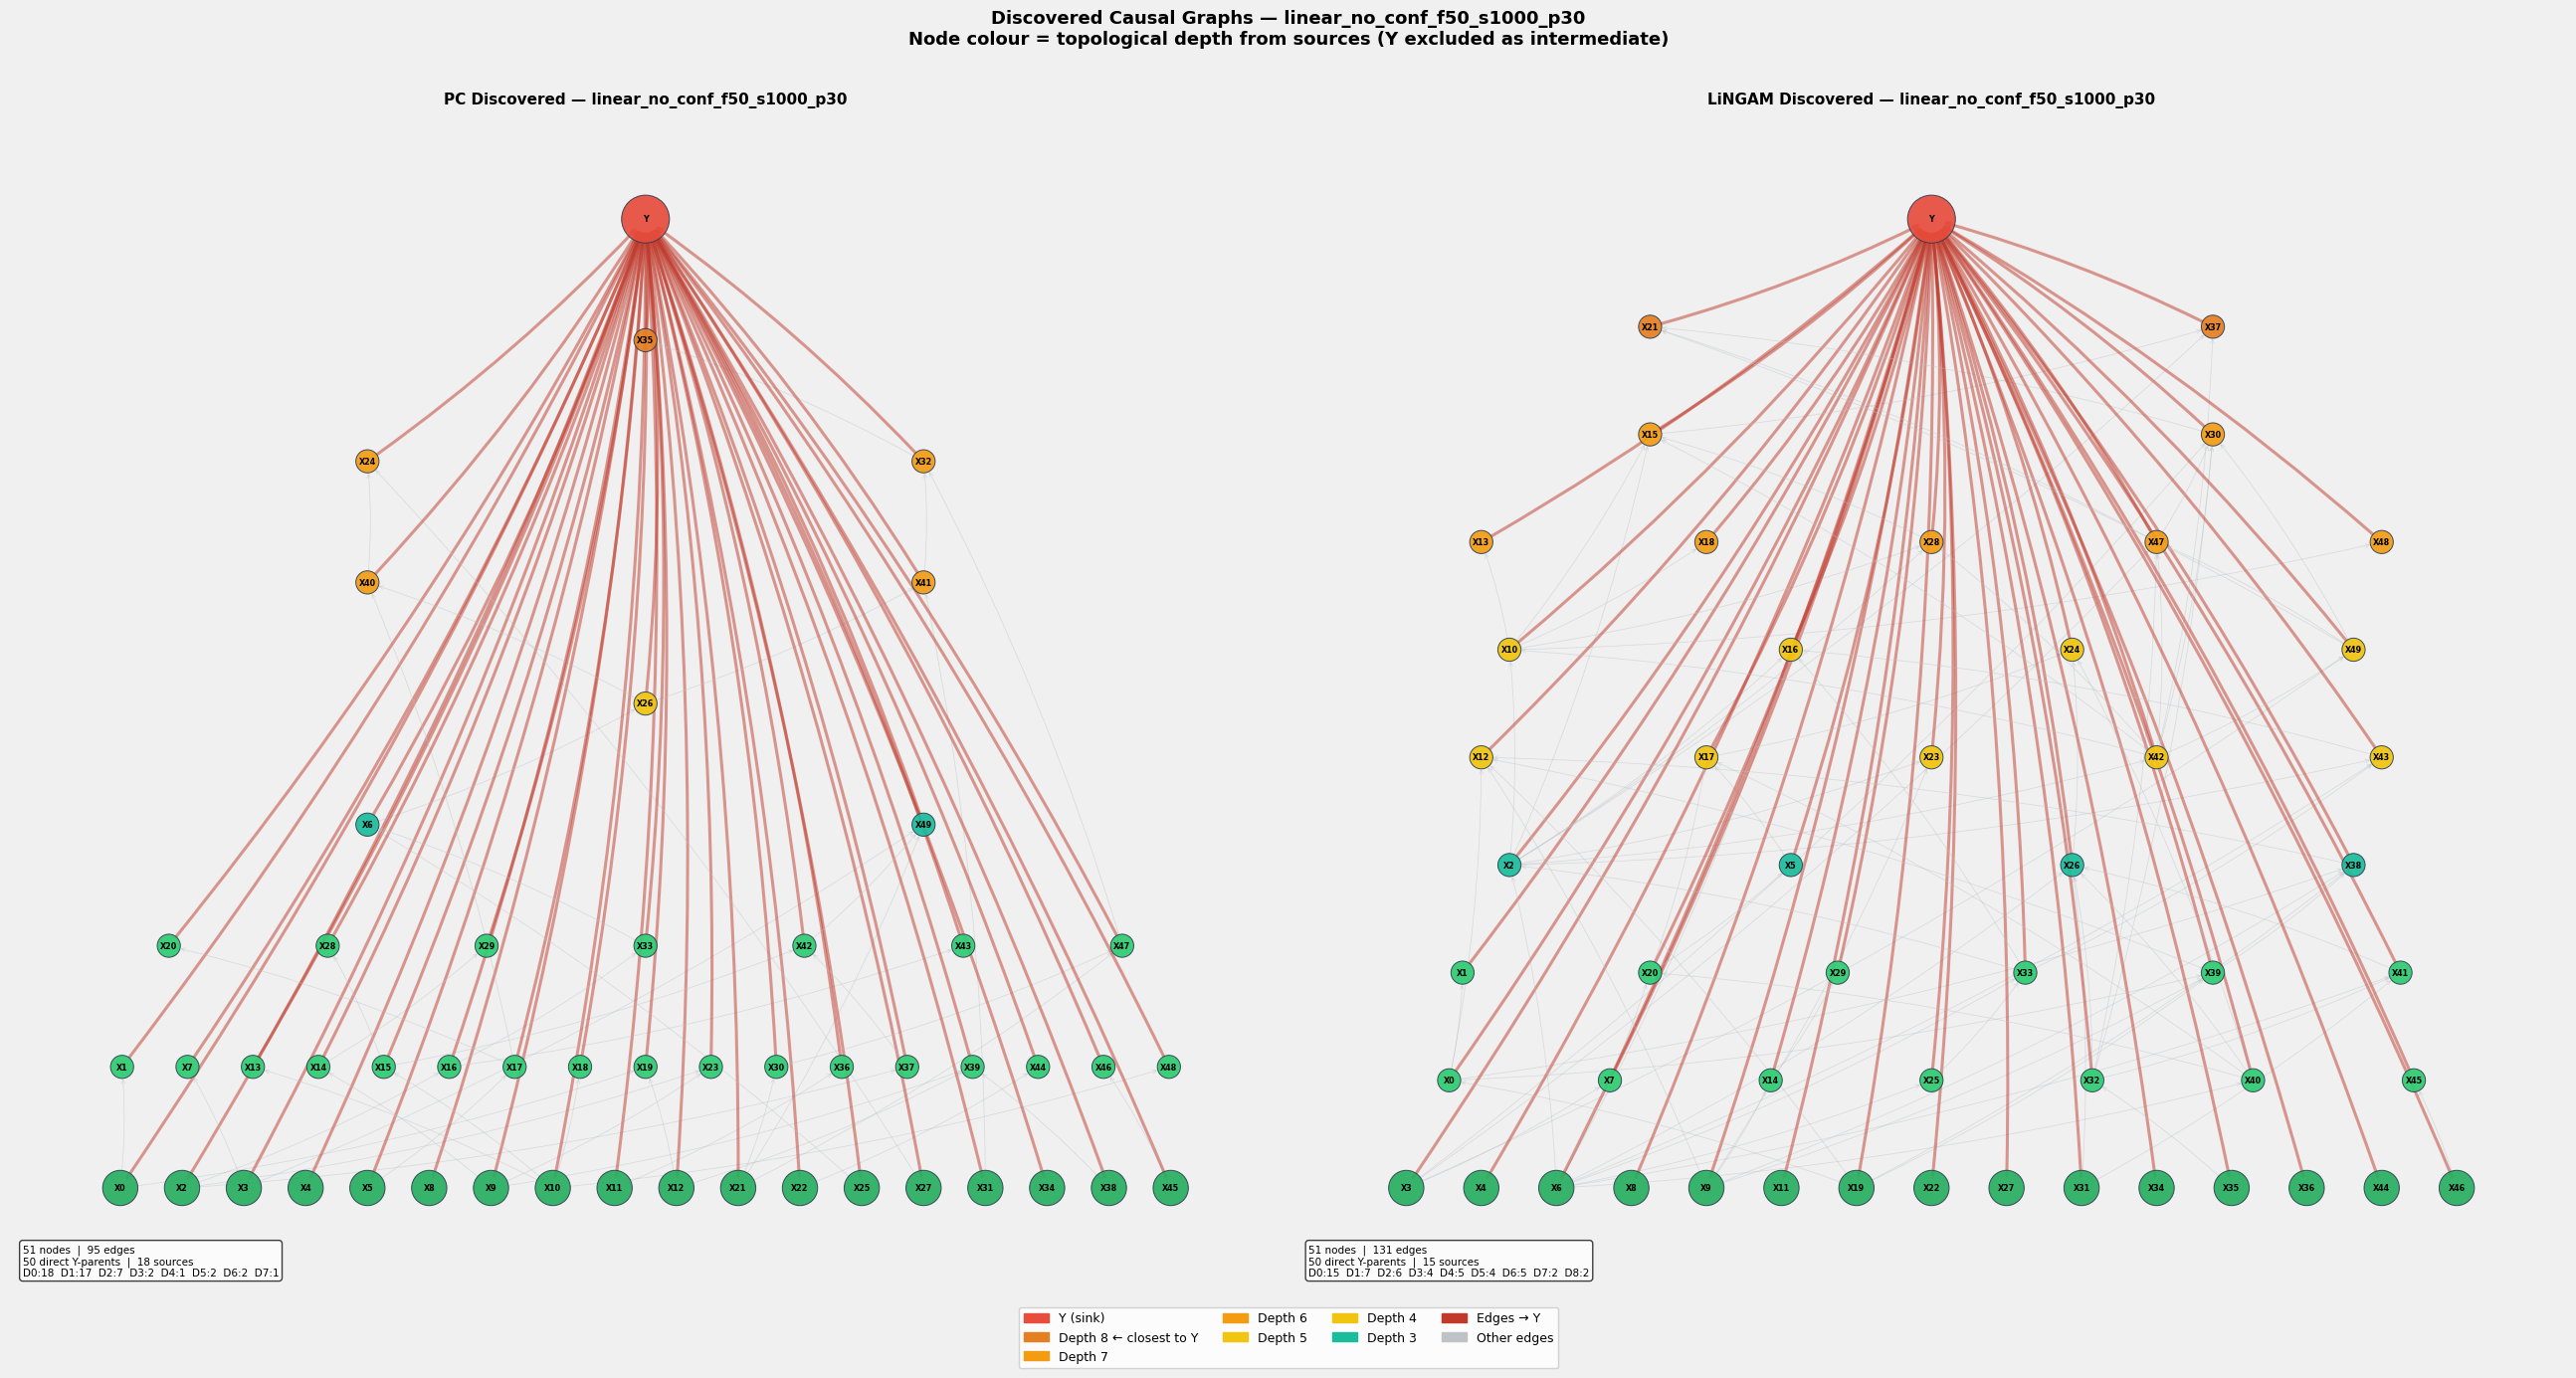


Metric                                 True         PC     LiNGAM
────────────────────────────────────────────────────────────────
  Total nodes                           51        51        51
  Total edges                          137        95       131
  Direct Y-parents                      50        50        50
  Source nodes (depth 0)                10        18        15
  Max topo depth                         7         7         8
  Nodes at depth 0                      10        18        15
  Nodes at depth 1                       9        17         7
  Nodes at depth 2                       9         7         6
  Nodes at depth 3                       8         2         4
  Nodes at depth 4                       7         1         5
  Nodes at depth 5                       4         2         4
  Nodes at depth 6                       2         2         5
  Nodes at depth 7                       1         1         2
  Nodes at depth 8 (closest to Y)         0      

In [7]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import collections

# ── Load both discovery results + true adjacency for the current DATASET ─────
def load_dag(causal_dir, dataset, method):
    path = causal_dir / f"{dataset}_{method}_results.json"
    with open(path) as f:
        r = json.load(f)
    return np.array(r["adjacency_matrix"]), r["feature_names"]

pc_adj,     pc_names     = load_dag(CAUSAL_DIR, DATASET, "pc")
lingam_adj, lingam_names = load_dag(CAUSAL_DIR, DATASET, "lingam")

true_adj   = np.load(CAUSAL_DIR / f"{DATASET}_true_full_adjacency.npy")
true_names = pc_names  # same feature ordering (X0…X{n-1}, Y)

# ── Build all three graphs ────────────────────────────────────────────────────
G_true,   td_true,   lvg_true,   src_true,   y_true,   ml_true   = build_dag_graph(true_adj,   true_names)
G_pc,     td_pc,     lvg_pc,     src_pc,     y_pc,     ml_pc     = build_dag_graph(pc_adj,     pc_names)
G_lingam, td_lingam, lvg_lingam, src_lingam, y_lingam, ml_lingam = build_dag_graph(lingam_adj, lingam_names)

pos_true   = make_dag_pos(lvg_true,   ml_true)
pos_pc     = make_dag_pos(lvg_pc,     ml_pc)
pos_lingam = make_dag_pos(lvg_lingam, ml_lingam)

# ── Draw 2-panel figure: PC | LiNGAM ─────────────────────────────────────────
fig_dags = plot_dag_comparison(
    G_pc, pos_pc, td_pc, src_pc, y_pc, ml_pc,
    G_lingam, pos_lingam, td_lingam, src_lingam, y_lingam, ml_lingam,
    DATASET, PROX_PALETTE, save_dir=PLOTS_DIR,
)

# ── Comparison table: True | PC | LiNGAM ─────────────────────────────────────
rows = {}
for label, G, td, src, y_i, ml in [
    ("True",   G_true,   td_true,   src_true,   y_true,   ml_true),
    ("PC",     G_pc,     td_pc,     src_pc,     y_pc,     ml_pc),
    ("LiNGAM", G_lingam, td_lingam, src_lingam, y_lingam, ml_lingam),
]:
    rows[label] = {
        "nodes":      G.number_of_nodes(),
        "edges":      G.number_of_edges(),
        "direct_y":   sum(1 for u, v in G.edges() if v == y_i),
        "sources":    len(src),
        "max_depth":  ml,
        "depth_dist": collections.Counter(v for k, v in td.items() if k != y_i),
    }

def _fmt(d, key): return f"{d[key]:>10}"

print(f"\n{'Metric':<32} {'True':>10} {'PC':>10} {'LiNGAM':>10}")
print("─" * 64)
print(f"  {'Total nodes':<30}"            + "".join(_fmt(rows[m], "nodes")    for m in ["True","PC","LiNGAM"]))
print(f"  {'Total edges':<30}"            + "".join(_fmt(rows[m], "edges")    for m in ["True","PC","LiNGAM"]))
print(f"  {'Direct Y-parents':<30}"       + "".join(_fmt(rows[m], "direct_y") for m in ["True","PC","LiNGAM"]))
print(f"  {'Source nodes (depth 0)':<30}" + "".join(_fmt(rows[m], "sources")  for m in ["True","PC","LiNGAM"]))
print(f"  {'Max topo depth':<30}"         + "".join(_fmt(rows[m], "max_depth") for m in ["True","PC","LiNGAM"]))
max_d_all = max(rows[m]["max_depth"] for m in rows)
for d in range(max_d_all + 1):
    note = " (closest to Y)" if d == max_d_all else ""
    vals = "".join(f"{rows[m]['depth_dist'].get(d, 0):>10}" for m in ["True","PC","LiNGAM"])
    print(f"  {'Nodes at depth ' + str(d) + note:<30}" + vals)

# ── Edge recovery metrics ─────────────────────────────────────────────────────
pc_prec,     pc_rec,     pc_f1     = edge_recovery(true_adj, pc_adj)
lingam_prec, lingam_rec, lingam_f1 = edge_recovery(true_adj, lingam_adj)

print(f"\n{'Edge Recovery vs true_full_adj':<32} {'PC':>10} {'LiNGAM':>10}")
print("─" * 54)
print(f"  {'Precision':<30} {pc_prec:>10.3f} {lingam_prec:>10.3f}")
print(f"  {'Recall':<30} {pc_rec:>10.3f} {lingam_rec:>10.3f}")
print(f"  {'F1':<30} {pc_f1:>10.3f} {lingam_f1:>10.3f}")

### 6.1. True Causal Graph

Ground-truth DAG for comparison against the discovered PC and LiNGAM graphs above.

  ✅  Saved → plots/linear_no_conf_f50_s1000_p30/dag_true_linear_no_conf_f50_s1000_p30.png


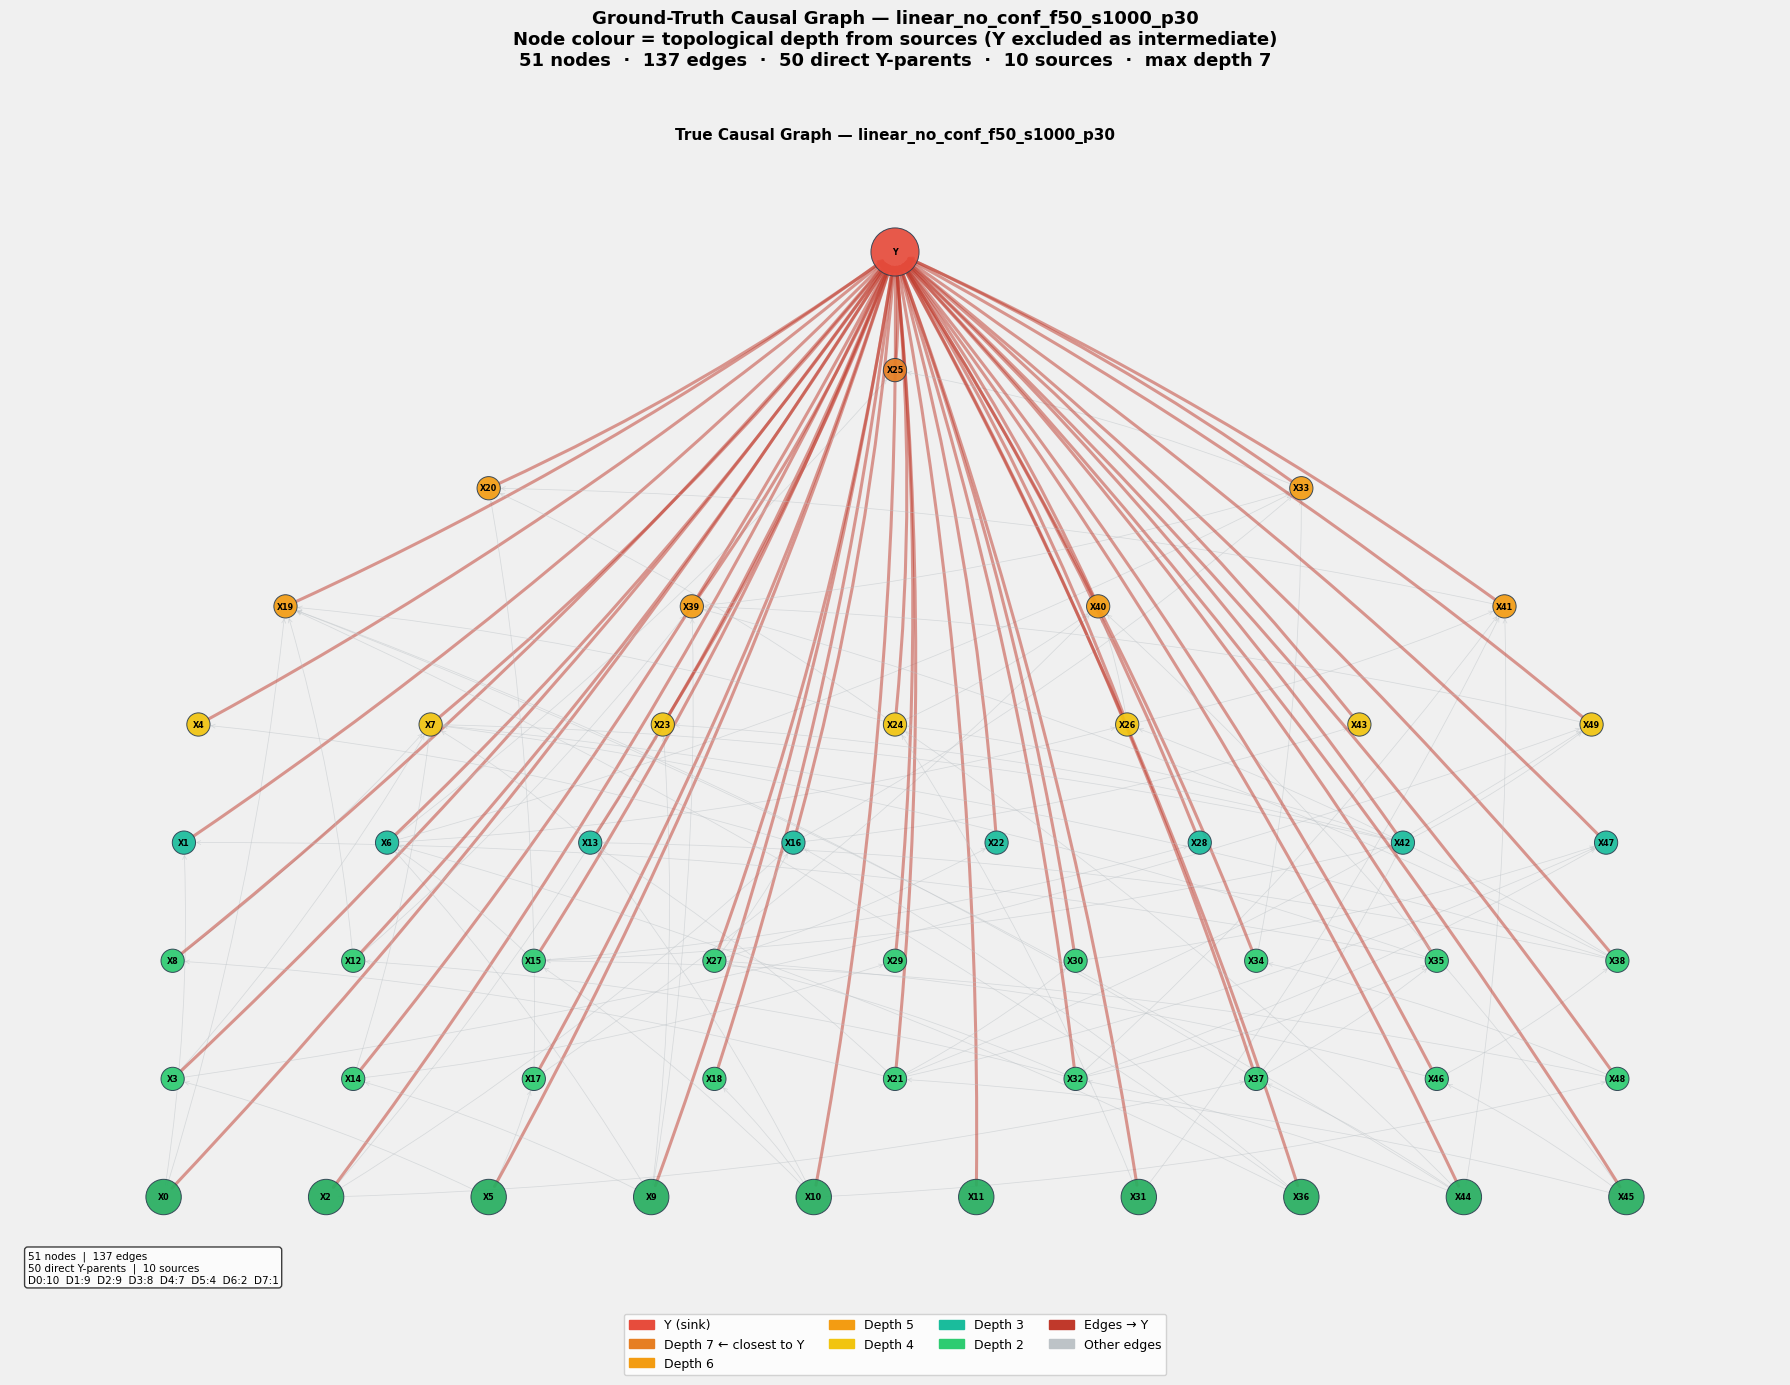

In [8]:
fig_true = plot_true_dag(
    G_true, pos_true, td_true, src_true, y_true, ml_true,
    DATASET, PROX_PALETTE, save_dir=PLOTS_DIR,
)

## 7. DAG Node Highlight: PC vs LiNGAM

Highlight a specific feature node in both PC and LiNGAM graphs to understand its causal role.  
**Blue** arrows = incoming edges (parents of the node).  
**Orange-red** arrows = outgoing edges (children of the node).  
All other nodes and edges are muted so the focal node stands out clearly.

In/out degree and topological depth are annotated at the bottom-left of each panel.  
Use this after the Graph Sensitivity Analysis (Section 9) to inspect features with high GSS, low SSS, or large rank shifts.

  ✅  Saved → plots/linear_no_conf_f50_s1000_p30/dag_highlight_X33_linear_no_conf_f50_s1000_p30.png


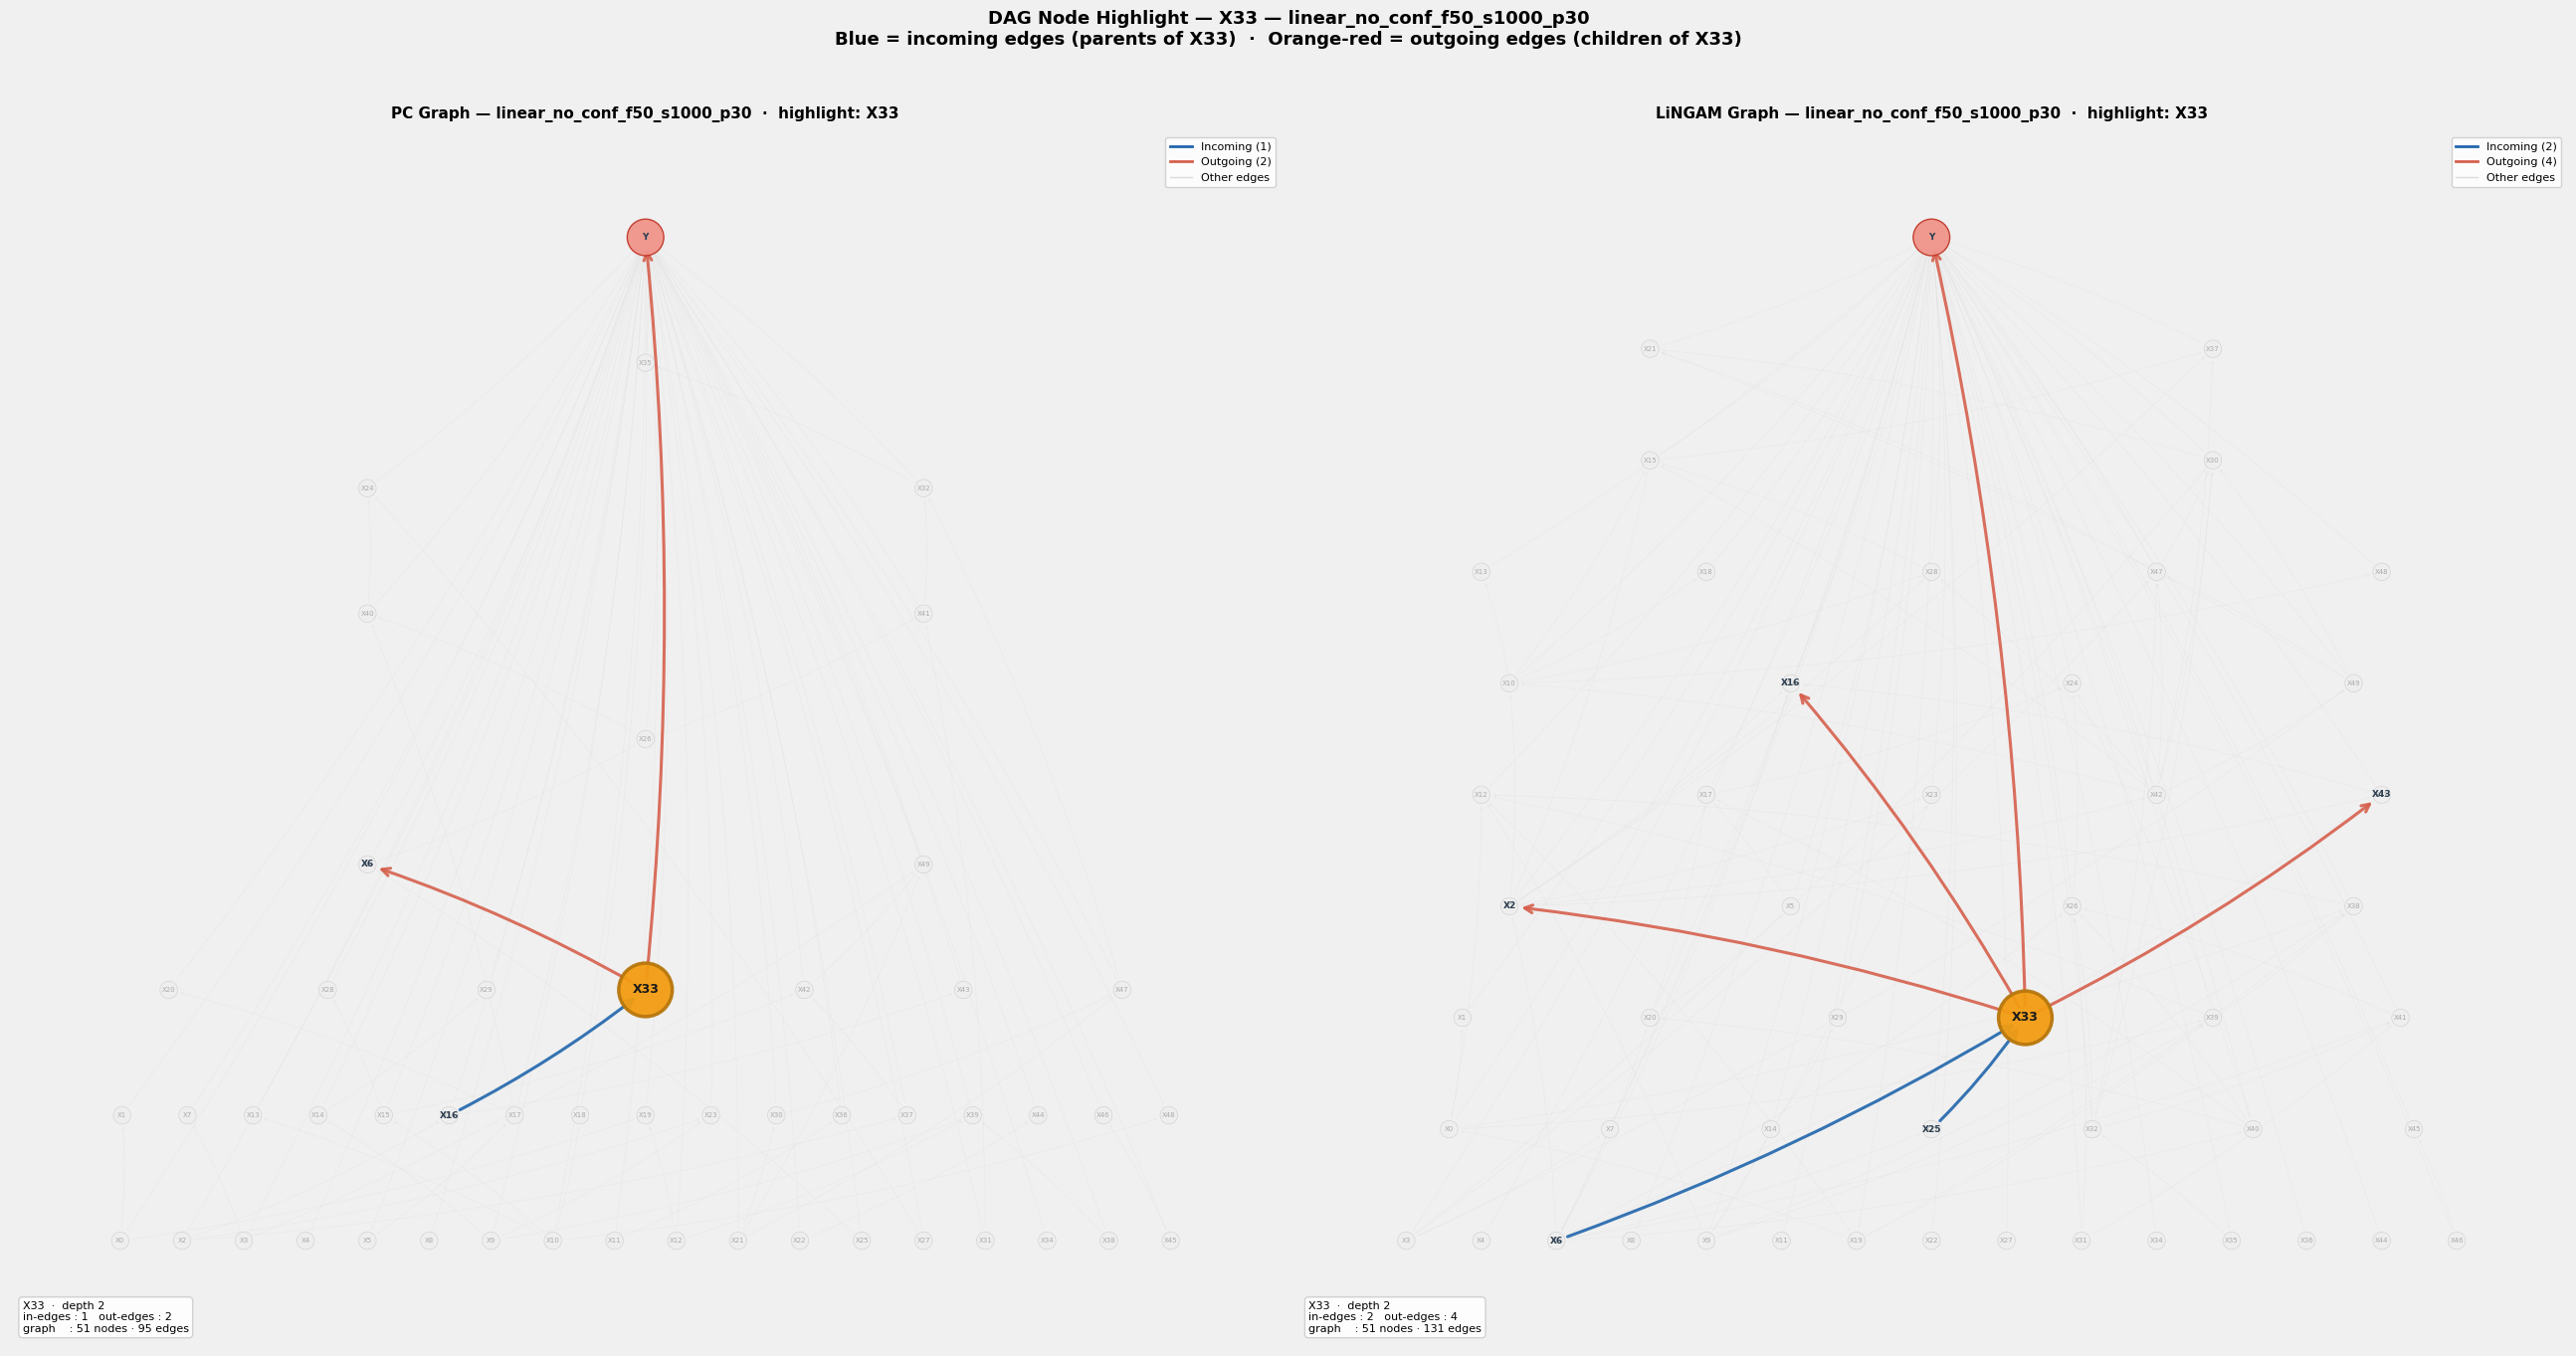

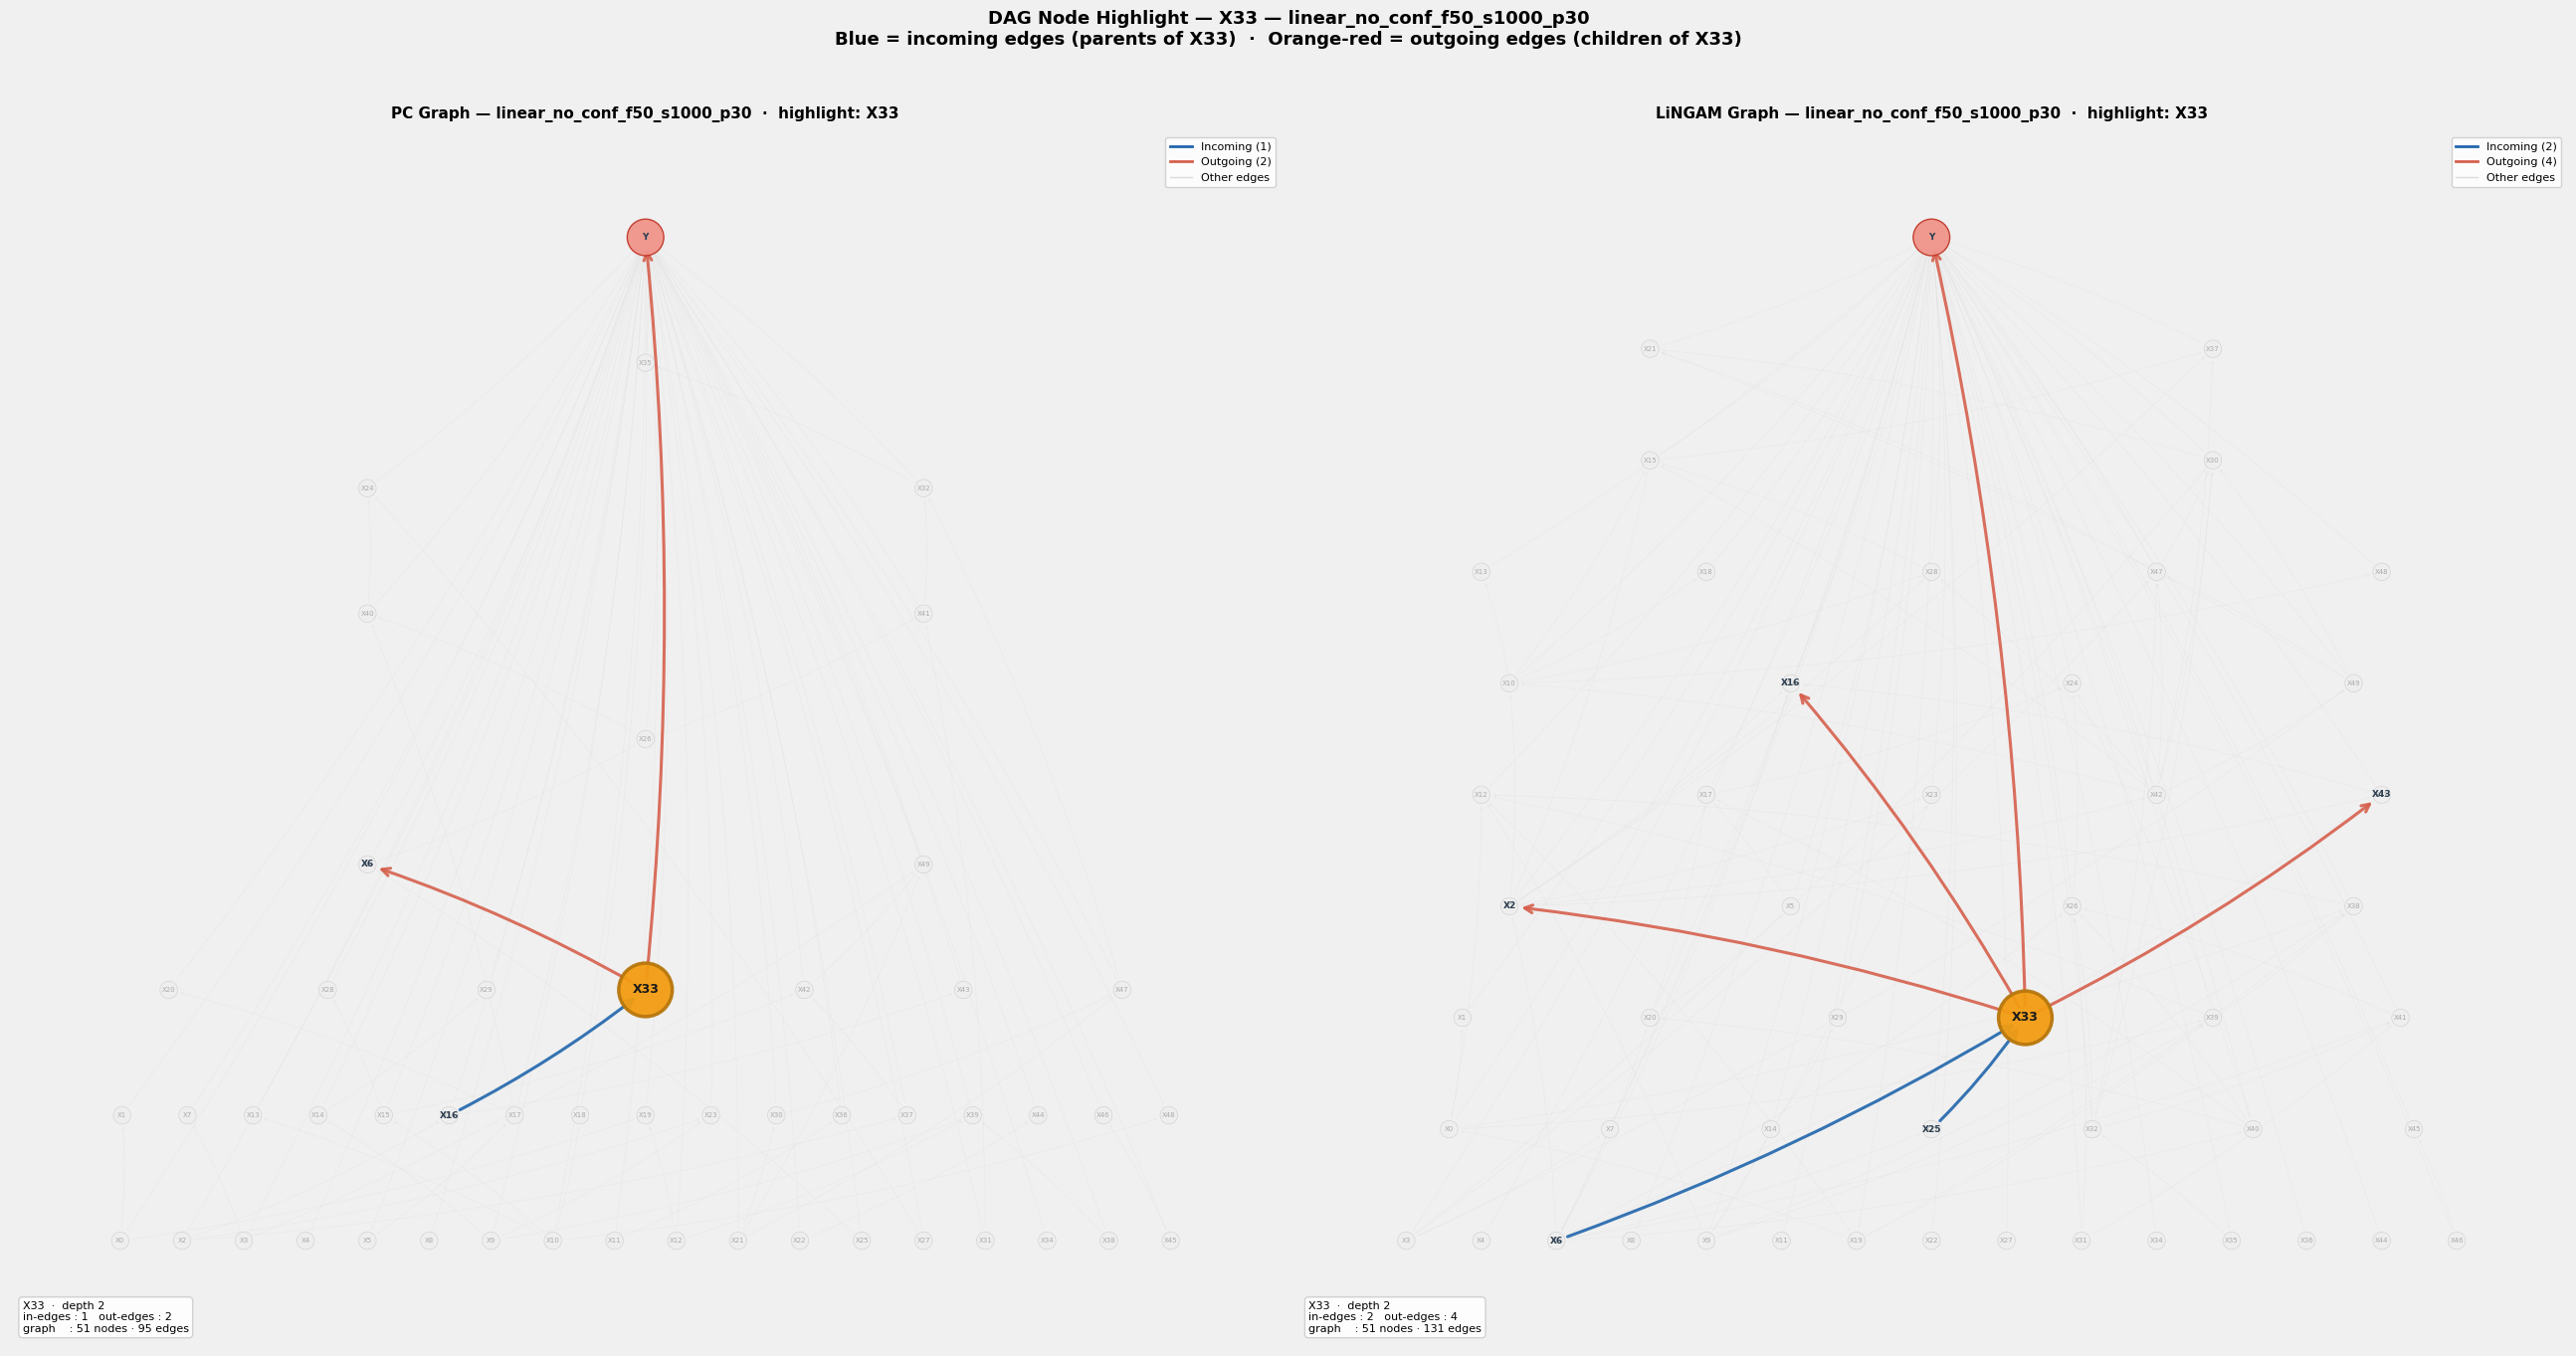

In [9]:
# Change the feature name to any node visible in Section 9 graphs,
# e.g. features identified as most unstable/stable from Section 8 diagnostics.
plot_dag_highlight(
    G_pc, pos_pc, td_pc, src_pc, y_pc, ml_pc,
    G_lingam, pos_lingam, td_lingam, src_lingam, y_lingam, ml_lingam,
    "X33", pc_names, DATASET, save_dir=PLOTS_DIR,
)

### 7.1. SHAP Attribution Comparison: PC vs LiNGAM

Instance-level bar charts and scatter plots comparing Shapley attributions under PC and LiNGAM graphs for the selected features. Columns: Traditional (no graph) | Method (PC) | Method (LiNGAM) | Method (True DAG).

In [10]:
features_names = ["X33", "X41", "X47", "X7", "X24"]
fig_instance_pc_vs_lingam = plot_instance_shap_pc_vs_lingam(
    shap_data, feature_names, scratch_rank, top_features, instance_idx,
    pc_edges, lingam_edges, DATASET, N_TOP_FEATURES,
    features=features_names,
)

In [11]:
fig_scatter_pc_vs_lingam = plot_shap_scatter_pc_vs_lingam(
    shap_data, feature_names, scratch_rank, top_features, x_test,
    pc_edges, lingam_edges, DATASET, N_TOP_FEATURES,
    features=features_names,
)

## 8. True DAG Node Highlight

Same highlight visualisation as Section 7 but drawn on the **ground-truth causal graph**.  
Use this alongside the PC / LiNGAM highlights to compare the node's true causal neighbourhood
against what each discovery algorithm found.

**Blue** arrows = incoming edges (parents of the node).  
**Orange-red** arrows = outgoing edges (children of the node).  
All other nodes and edges are muted.

  ✅  Saved → plots/linear_no_conf_f50_s1000_p30/dag_highlight_true_X29_linear_no_conf_f50_s1000_p30.png


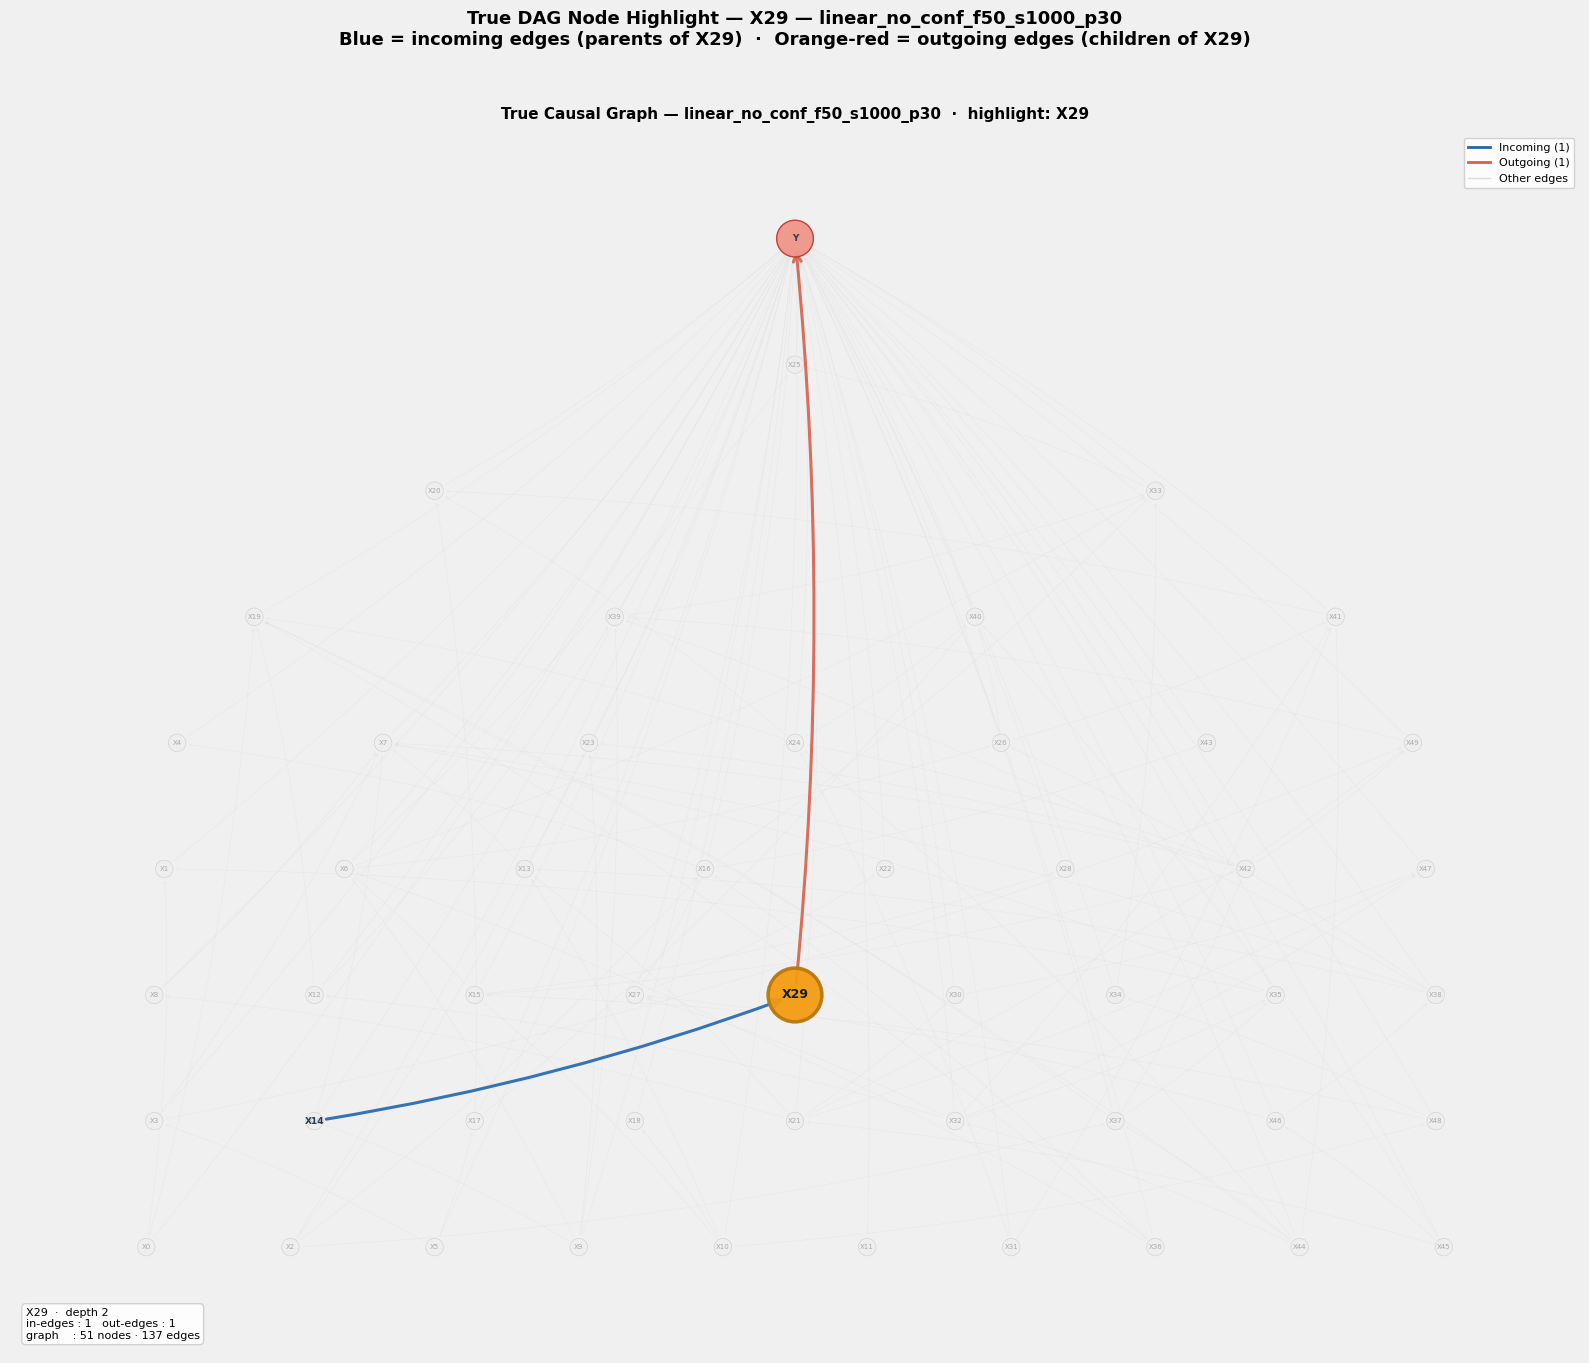

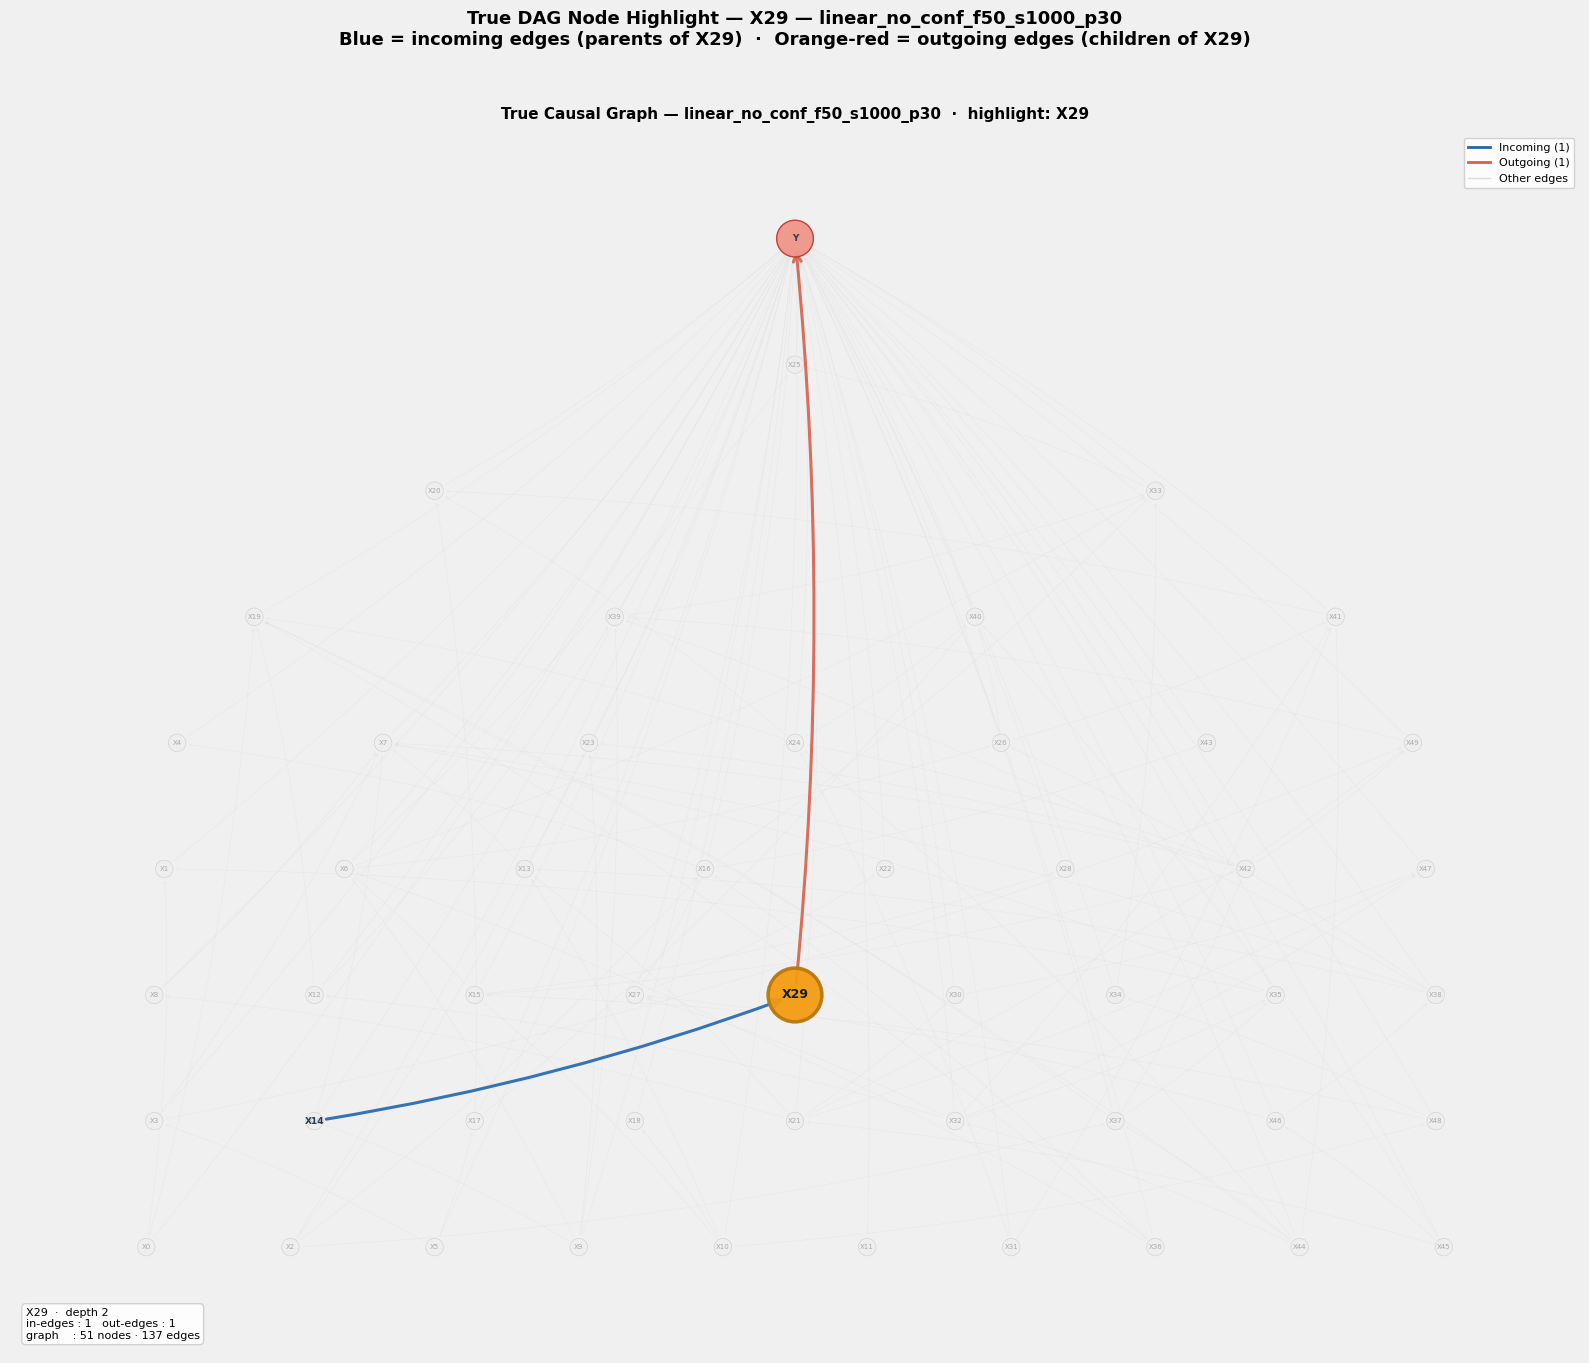

In [12]:
# Use the same feature name as in plot_dag_highlight() to compare the true
# causal neighbourhood against the PC and LiNGAM discovered neighbourhoods.
plot_dag_highlight_true(
    G_true, pos_true, td_true, src_true, y_true, ml_true,
    "X29", true_names, DATASET, save_dir=PLOTS_DIR,
)

## 9. Graph Sensitivity Analysis

**Goal**: quantify how much the choice of discovered graph (PC vs LiNGAM vs ground truth) changes the attributions produced by each causal Shapley method. This lets us answer the key thesis question:

> *Which method is causally aware but robust to graph quality?*

### Strategy

| Step | Metric | Graph variants | Instances used |
|------|--------|----------------|----------------|
| 9.1 | Load pre-computed Shapley values from pipeline output | All (PC / LiNGAM / True) | All pipeline test instances (~100) |
| 9.2 | **Graph Sensitivity Score (GSS)** — importance-magnitude change between PC and LiNGAM | PC vs LiNGAM | All pre-computed instances |
| 9.3 | **Ranking Robustness** — Spearman ρ, Top-K Jaccard, True-parent Precision@K | PC vs LiNGAM vs True | All pre-computed instances |
| 9.4 | **Sign Stability Score (SSS)** — sign agreement between PC and LiNGAM attributions | PC vs LiNGAM | All pre-computed instances |
| 9.5 | **Recommendation summary** — aggregated score per method | All variants | — |

> **Run Section 3 first** (cells through "Load Shapley Values") to populate `shap_data`, `feature_names`, `x_test`, etc.

### 9.1. Load SHAP Values (All Methods × Graphs)

Load pre-computed Shapley values for all combinations of causal method (Asymmetric, Causal, Flow) × graph (PC, LiNGAM, True) from pipeline output. No re-computation is required.

In [13]:
"""
10.1 — Load pre-computed Shapley values (all 3 methods × 3 graphs) from pipeline output.

The pipeline (calculate_all_shapley_values) already computed and saved every combination
to data/explainability/{DATASET}/lgbm/{graph}/{method}/shapley_values.npy.
No re-computation or caching is needed here.
"""
_exp_base = EXPLAINABILITY_DIR / DATASET / "lgbm"

PIPELINE_KEYS = {
    "Asymmetric (PC)":     _exp_base / "pc"     / "asymmetric" / "shapley_values.npy",
    "Causal (PC)":         _exp_base / "pc"     / "causal"     / "shapley_values.npy",
    "Flow (PC)":           _exp_base / "pc"     / "flow"       / "shapley_values.npy",
    "Asymmetric (LiNGAM)": _exp_base / "lingam" / "asymmetric" / "shapley_values.npy",
    "Causal (LiNGAM)":     _exp_base / "lingam" / "causal"     / "shapley_values.npy",
    "Flow (LiNGAM)":       _exp_base / "lingam" / "flow"       / "shapley_values.npy",
    "Asymmetric (True)":   _exp_base / "true"   / "asymmetric" / "shapley_values.npy",
    "Causal (True)":       _exp_base / "true"   / "causal"     / "shapley_values.npy",
    "Flow (True)":         _exp_base / "true"   / "flow"       / "shapley_values.npy",
}

subset_shap_data = {}
for key, path in PIPELINE_KEYS.items():
    if path.exists():
        subset_shap_data[key] = np.load(path)
    else:
        print(f"⚠️  Missing: {path}")

# ── Auxiliary variables expected by downstream cells ─────────────────────────
_train_tmp    = pd.read_parquet(PROCESSED_DIR / f"{DATASET}_train.parquet")
_test_tmp     = pd.read_parquet(PROCESSED_DIR / f"{DATASET}_test.parquet")
feat_names_10 = [c for c in _train_tmp.drop(columns=["Y"]).columns]

X_train_10 = _train_tmp.drop(columns=["Y"]); y_train_10 = _train_tmp["Y"]
X_test_10  = _test_tmp.drop(columns=["Y"]);  y_test_10  = _test_tmp["Y"]

RANDOM_STATE_10 = 42
N_TRUE_INSTANCES = list(subset_shap_data.values())[0].shape[0]

true_adj_xx         = true_adj[:len(feat_names_10), :len(feat_names_10)]
pc_train_adj_xx     = np.load(CAUSAL_DIR / f"{DATASET}_pc_train_adjacency.npy")
lingam_train_adj_xx = np.load(CAUSAL_DIR / f"{DATASET}_lingam_train_adjacency.npy")

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"✅  Loaded {len(subset_shap_data)} arrays from pipeline output.")
print(f"    Instances per array: {N_TRUE_INSTANCES}  |  Features: {list(subset_shap_data.values())[0].shape[1]}\n")
print(f"{'Key':<28}  {'Shape':>14}  {'mean|φ|':>9}  {'zeros%':>7}")
print("─" * 65)
for k, v in subset_shap_data.items():
    print(f"  {k:<26}  {str(v.shape):>14}  {np.abs(v).mean():>9.4f}  {100*(v==0).mean():>6.1f}%")


✅  Loaded 9 arrays from pipeline output.
    Instances per array: 100  |  Features: 50

Key                                    Shape    mean|φ|   zeros%
─────────────────────────────────────────────────────────────────
  Asymmetric (PC)                  (100, 50)     0.2438     0.0%
  Causal (PC)                      (100, 50)     0.3870     0.0%
  Flow (PC)                        (100, 50)     0.2948    12.6%
  Asymmetric (LiNGAM)              (100, 50)     0.2444     0.0%
  Causal (LiNGAM)                  (100, 50)     0.3583     0.0%
  Flow (LiNGAM)                    (100, 50)     0.2809    12.6%
  Asymmetric (True)                (100, 50)     0.2453     0.0%
  Causal (True)                    (100, 50)     0.3656     0.0%
  Flow (True)                      (100, 50)     0.2571     8.2%


### 9.2. Graph Sensitivity Score (GSS)

The **Graph Sensitivity Score** measures how much the choice of causal discovery algorithm (PC vs LiNGAM) changes the **importance magnitude** assigned to each feature. It operates on absolute Shapley values so that sign flips that preserve magnitude do not inflate the score:

$$
\text{GSS}(m, f) = \frac{\displaystyle\frac{1}{n}\sum_{i=1}^{n}\Bigl|\,|\varphi^{(m,\,\text{PC})}_{i,f}| - |\varphi^{(m,\,\text{LiNGAM})}_{i,f}|\,\Bigr|}{\displaystyle\max_{m'}\;\frac{1}{n}\sum_{i=1}^{n}\Bigl|\,|\varphi^{(m',\,\text{PC})}_{i,f}| - |\varphi^{(m',\,\text{LiNGAM})}_{i,f}|\,\Bigr|}
$$

where $m$ is the causal Shapley method (Asymmetric, Causal, Flow), $f$ is a feature, $n$ is the number of instances, and $\varphi^{(m,\,g)}_{i,f}$ is the Shapley value of feature $f$ for instance $i$ under method $m$ with graph $g$.

The denominator is the **per-feature maximum** of this magnitude difference across methods, bounding **GSS $\in [0,\,1]$** for every feature:

- **GSS = 0** — both graphs assign the same importance magnitude (the feature matters equally under PC and LiNGAM).
- **GSS = 1** — this method shows the largest importance-magnitude shift for this feature across all methods.

This normalisation answers: *"relative to the most sensitive method, how much does graph choice change the importance of feature $f$ for method $m$?"* A method with low mean GSS is **robust** to which causal discovery algorithm was used.

In [14]:
"""
10.2 — Graph Sensitivity Score (GSS): PC vs LiNGAM
"""
CAUSAL_METHOD_PAIRS = [
    ("Asymmetric", "Asymmetric (PC)",  "Asymmetric (LiNGAM)"),
    ("Causal",     "Causal (PC)",      "Causal (LiNGAM)"),
    ("Flow",       "Flow (PC)",        "Flow (LiNGAM)"),
]

# ── Compute signed magnitude delta ───────────────────────────────────────────
feat_delta = {}
gss_feat   = {}
for label, pc_key, lingam_key in CAUSAL_METHOD_PAIRS:
    if pc_key not in shap_data or lingam_key not in shap_data:
        continue
    abs_pc              = np.abs(shap_data[pc_key])
    abs_lingam          = np.abs(shap_data[lingam_key])
    feat_delta[label]   = abs_pc - abs_lingam
    gss_feat[label]     = feat_delta[label].mean(axis=0)

for label in ["Asymmetric", "Causal", "Flow"]:
    if label not in gss_feat:
        continue
    g = gss_feat[label]
    print(f"{label}: mean GSS = {np.mean(g):.4f}  "
          f"min GSS = {np.min(g):.4f}  max GSS = {np.max(g):.4f}")

# ── A: Feature-level GSS heatmap ─────────────────────────────────────────────
fig_gss_hmap = plot_gss_heatmap(
    gss_feat, feature_names, BASE_METHODS, DATASET, save_dir=PLOTS_DIR,
)

# ── B: Per-instance magnitude delta box plots ────────────────────────────────
fig_delta = plot_gss_delta_box(
    feat_delta, feature_names, scratch_rank, METHOD_COLORS, DATASET,
    N_TOP_FEATURES, save_dir=PLOTS_DIR,
)

# ── C: Method-level GSS summary ──────────────────────────────────────────────
print(f"\n{'Method':<15}  {'Mean GSS':>10}  {'Median GSS':>11}  {'Max |GSS|':>10}  "
      f"{'Feat |GSS|>0.5':>14}  {'Feat |GSS|>0.1':>14}")
print("─" * 85)
for label in ["Asymmetric", "Causal", "Flow"]:
    if label not in gss_feat:
        continue
    g = gss_feat[label]
    print(f"  {label:<13}  {np.mean(g):>10.4f}  {np.median(g):>11.4f}  "
          f"{np.max(np.abs(g)):>10.4f}  {(np.abs(g)>0.5).sum():>14d}  {(np.abs(g)>0.1).sum():>14d}")

Asymmetric: mean GSS = -0.0005  min GSS = -0.0240  max GSS = 0.0350
Causal: mean GSS = 0.0288  min GSS = -1.9668  max GSS = 1.6532
Flow: mean GSS = 0.0139  min GSS = -0.7597  max GSS = 0.8151


  ✅  Saved → plots/linear_no_conf_f50_s1000_p30/gss_heatmap_linear_no_conf_f50_s1000_p30.png


  ✅  Saved → plots/linear_no_conf_f50_s1000_p30/gss_delta_box_linear_no_conf_f50_s1000_p30.png

Method             Mean GSS   Median GSS   Max |GSS|  Feat |GSS|>0.5  Feat |GSS|>0.1
─────────────────────────────────────────────────────────────────────────────────────
  Asymmetric        -0.0005      -0.0004      0.0350               0               0
  Causal             0.0288       0.0019      1.9668              10              24
  Flow               0.0139       0.0003      0.8151               7              21


### 9.3. Ranking Robustness & True-Parent Recovery

Spearman rank correlation between each method's feature ranking and the Scratch baseline, Top-K Jaccard overlap, and true-parent Precision@K — measuring how faithfully the discovered graph preserves causal feature rankings relative to the ground truth.

In [15]:
"""
10.3 — Ranking Robustness vs Scratch & True-parent Recovery
"""
from scipy.stats import spearmanr

# ── Load true Y-parent set ────────────────────────────────────────────────────
with open(SYNTHETIC_DIR / f"{DATASET}_metadata.json") as _f:
    _meta = json.load(_f)
y_parent_set = set(_meta["y_parent_indices"])
print(f"True Y-parents: {len(y_parent_set)} / {len(feature_names)} features")
random_baseline = len(y_parent_set) / len(feature_names)
print(f"Random baseline precision: {random_baseline:.3f}")

scratch_ma = mean_abs_shap(shap_data, "Scratch")

# ── Compute Spearman ρ ────────────────────────────────────────────────────────
spearman_data = {}
for meth in BASE_METHODS:
    for g in DISC_GRAPHS:
        k = f"{meth} ({g})"
        if k not in shap_data:
            continue
        rho, _ = spearmanr(mean_abs_shap(shap_data, k), scratch_ma)
        spearman_data[(meth, g)] = float(rho)

# ── Jaccard rows ─────────────────────────────────────────────────────────────
jaccard_rows = []
for meth in BASE_METHODS:
    for g in DISC_GRAPHS:
        k = f"{meth} ({g})"
        if k not in shap_data:
            continue
        for kv in K_VALUES:
            j = top_k_jaccard(mean_abs_shap(shap_data, k), scratch_ma, kv)
            jaccard_rows.append(dict(Method=meth, Graph=g, K=f"Top-{kv}", Jaccard=j))
df_jacc = pd.DataFrame(jaccard_rows)

# ── Parent precision rows ─────────────────────────────────────────────────────
parent_rows = []
for meth_key, meth_label in [("Scratch", "Scratch")] + \
                              [(f"{m} ({g})", f"{m} ({g})") for m in BASE_METHODS for g in DISC_GRAPHS]:
    if meth_key not in shap_data:
        continue
    ma = mean_abs_shap(shap_data, meth_key)
    for kv in K_VALUES:
        top_k_idx = set(np.argsort(ma)[-kv:])
        prec = len(top_k_idx & y_parent_set) / kv
        parent_rows.append(dict(Method=meth_label, K=f"Top-{kv}", Precision=prec))
df_parent = pd.DataFrame(parent_rows)

# ── A: Spearman heatmap ───────────────────────────────────────────────────────
fig_spearman = plot_spearman_heatmap(
    spearman_data, BASE_METHODS, DISC_GRAPHS, DATASET, n_shap, save_dir=PLOTS_DIR,
)

# ── B: Jaccard bar chart ──────────────────────────────────────────────────────
fig_jacc = plot_jaccard_bar(df_jacc, METHOD_COLORS, DATASET, save_dir=PLOTS_DIR)

# ── C: True-parent Precision@K ────────────────────────────────────────────────
fig_parent = plot_parent_precision_bar(
    df_parent, METHOD_COLORS, DATASET, DISC_GRAPHS, random_baseline, save_dir=PLOTS_DIR,
)

# ── Stub: tga_data is populated in Section 11 ─────────────────────────────────
tga_data = {}

True Y-parents: 15 / 50 features
Random baseline precision: 0.300


  ✅  Saved → plots/linear_no_conf_f50_s1000_p30/spearman_heatmap_linear_no_conf_f50_s1000_p30.png


  ✅  Saved → plots/linear_no_conf_f50_s1000_p30/jaccard_bar_linear_no_conf_f50_s1000_p30.png


  ✅  Saved → plots/linear_no_conf_f50_s1000_p30/parent_precision_bar_linear_no_conf_f50_s1000_p30.png


### 9.4. Sign Stability Score (SSS): PC vs LiNGAM

**SSS** is the sign-domain counterpart to GSS. Instead of comparing *magnitudes*, it asks for each (instance, feature) pair whether the **sign** of the SHAP value agrees between the PC and LiNGAM graph.

$$
\text{SSS}(m, f) = \frac{1}{|\{i : \varphi^{(m,\text{PC})}_{i,f} \neq 0 \;\wedge\; \varphi^{(m,\text{LiNGAM})}_{i,f} \neq 0\}|} \sum_i \mathbf{1}\!\left[\text{sign}\!\left(\varphi^{(m,\text{PC})}_{i,f}\right) = \text{sign}\!\left(\varphi^{(m,\text{LiNGAM})}_{i,f}\right)\right]
$$

- **SSS = 1** — the sign of this feature's attribution is always the same under PC and LiNGAM (fully stable direction).
- **SSS = 0** — the sign always flips (completely unstable direction).
- Instances where either attribution is exactly zero are excluded per-instance.

Read alongside GSS: a feature can have **low GSS** (magnitudes agree) but **low SSS** (directions flip), or high GSS (magnitudes shift a lot) but high SSS (direction is consistent). The combination tells the full story of graph sensitivity.

In [16]:
"""
10.4 — Sign Stability Score (SSS): PC vs LiNGAM
"""
sss_feat = compute_sss(shap_data, BASE_METHODS)

for meth, arr in sss_feat.items():
    print(f"{meth}: mean SSS = {np.nanmean(arr):.4f}  "
          f"min SSS = {np.nanmin(arr):.4f}  "
          f"features with SSS<0.5 = {(arr < 0.5).sum()}")

# ── A: Feature-level SSS heatmap ─────────────────────────────────────────────
fig_sign_hmap = plot_sss_heatmap(
    sss_feat, feature_names, BASE_METHODS, DATASET, save_dir=PLOTS_DIR,
)

# ── B: Method-level SSS bar chart ────────────────────────────────────────────
fig_sign_bar = plot_sss_bar(sss_feat, BASE_METHODS, METHOD_COLORS, DATASET, save_dir=PLOTS_DIR)

# ── C: Numeric summary ────────────────────────────────────────────────────────
print(f"\n{'Method':<15}  {'Mean SSS':>10}  {'Median SSS':>11}  {'Min SSS':>9}  "
      f"{'SSS<0.5':>8}  {'SSS<0.7':>8}")
print("─" * 68)
for meth in BASE_METHODS:
    if meth not in sss_feat:
        continue
    arr   = sss_feat[meth]
    valid = ~np.isnan(arr)
    print(f"  {meth:<13}  {np.nanmean(arr):>10.4f}  {np.nanmedian(arr):>11.4f}  "
          f"{np.nanmin(arr):>9.4f}  {(arr[valid]<0.5).sum():>8d}  {(arr[valid]<0.7).sum():>8d}")

Asymmetric: mean SSS = 0.9524  min SSS = 0.7700  features with SSS<0.5 = 0
Causal: mean SSS = 0.6144  min SSS = 0.3300  features with SSS<0.5 = 9
Flow: mean SSS = 0.8684  min SSS = 0.3409  features with SSS<0.5 = 2


  ✅  Saved → plots/linear_no_conf_f50_s1000_p30/sss_heatmap_linear_no_conf_f50_s1000_p30.png


  ✅  Saved → plots/linear_no_conf_f50_s1000_p30/sss_bar_linear_no_conf_f50_s1000_p30.png

Method             Mean SSS   Median SSS    Min SSS   SSS<0.5   SSS<0.7
────────────────────────────────────────────────────────────────────
  Asymmetric         0.9524       0.9700     0.7700         0         0
  Causal             0.6144       0.6000     0.3300         9        35
  Flow               0.8684       0.9253     0.3409         2         7


### 9.5. Method Recommendation Summary

Aggregated comparison table combining GSS, Spearman ρ, Top-K Jaccard, Precision@K, and TGA into a single method-level summary to identify the best-performing causal Shapley method for this dataset.

In [17]:
"""
10.4 — Method Recommendation Summary
"""
def _parent_prec(method_key, k):
    if method_key not in shap_data:
        return np.nan
    ma      = mean_abs_shap(shap_data, method_key)
    top_idx = set(np.argsort(ma)[-k:])
    return len(top_idx & y_parent_set) / k

summary_rows = []
for meth in BASE_METHODS:
    pc_key  = f"{meth} (PC)"
    lg_key  = f"{meth} (LiNGAM)"

    gss_mean   = float(gss_feat[meth].mean())         if meth in gss_feat     else np.nan
    rho_pc_scr = spearman_data.get((meth, "PC"),     np.nan)
    rho_lg_scr = spearman_data.get((meth, "LiNGAM"), np.nan)

    j20_pc  = top_k_jaccard(mean_abs_shap(shap_data, pc_key), scratch_ma, 20) \
              if pc_key in shap_data else np.nan
    j20_lg  = top_k_jaccard(mean_abs_shap(shap_data, lg_key), scratch_ma, 20) \
              if lg_key in shap_data else np.nan

    pp20_pc = _parent_prec(pc_key,  20)
    pp20_lg = _parent_prec(lg_key,  20)

    tga_pc  = float(tga_data[(meth,"PC")].mean())     if (meth,"PC")     in tga_data else np.nan
    tga_lg  = float(tga_data[(meth,"LiNGAM")].mean()) if (meth,"LiNGAM") in tga_data else np.nan

    summary_rows.append(dict(
        Method=meth, GSS=gss_mean,
        rho_pc=rho_pc_scr, rho_lg=rho_lg_scr,
        J20_pc=j20_pc, J20_lg=j20_lg,
        PP20_pc=pp20_pc, PP20_lg=pp20_lg,
        TGA_pc=tga_pc, TGA_lg=tga_lg,
    ))

# Reference row: Scratch
pp20_scratch = _parent_prec("Scratch", 20)
summary_rows.insert(0, dict(
    Method="Scratch", GSS=np.nan, rho_pc=np.nan, rho_lg=np.nan,
    J20_pc=np.nan, J20_lg=np.nan,
    PP20_pc=pp20_scratch, PP20_lg=pp20_scratch,
    TGA_pc=np.nan, TGA_lg=np.nan,
))
df_summary = pd.DataFrame(summary_rows)

fig_summary = plot_summary_table(
    df_summary, DATASET, n_shap, N_TRUE_INSTANCES, random_baseline, tga_data,
    save_dir=PLOTS_DIR,
)

# ── Text interpretation ───────────────────────────────────────────────────────
print("\n" + "="*72)
print("INTERPRETATION GUIDE")
print("="*72)
print(f"""
  GSS (↓): Max-normalised attribution shift between PC and LiNGAM graphs.
  ρ vs Scratch (↑): Spearman rank correlation vs graph-free Scratch baseline.
  J20 vs Scratch (↑): Top-20 Jaccard overlap with Scratch's top-20.
  P@20 (↑): Fraction of top-20 features that are true causal parents of Y.
    Random baseline = {random_baseline:.3f}.
  TGA (↓): Mean deviation from True-graph attributions
    (computed on {N_TRUE_INSTANCES} instances).
""")

  ✅  Saved → plots/linear_no_conf_f50_s1000_p30/summary_table_linear_no_conf_f50_s1000_p30.png

INTERPRETATION GUIDE

  GSS (↓): Max-normalised attribution shift between PC and LiNGAM graphs.
  ρ vs Scratch (↑): Spearman rank correlation vs graph-free Scratch baseline.
  J20 vs Scratch (↑): Top-20 Jaccard overlap with Scratch's top-20.
  P@20 (↑): Fraction of top-20 features that are true causal parents of Y.
    Random baseline = 0.300.
  TGA (↓): Mean deviation from True-graph attributions
    (computed on 100 instances).



## 10. True-Graph Alignment (TGA)

Requires `subset_shap_data` from section 9.1 (run that cell first).

We assess how well each causal Shapley method + discovered graph (PC, LiNGAM) recovers the attributions that would be obtained if the **true causal graph** were known. Two complementary lenses:

- **10.1 Sign Alignment** — does the discovered-graph attribution agree in *sign* with the true-graph attribution?
- **10.2 Magnitude Alignment** — how much does importance magnitude shift relative to the true-graph baseline?

### 10.1. Sign Alignment vs True Graph

For each instance $i$ and feature $f$, does the discovered-graph attribution agree in **sign** with the true-graph attribution?

$$
\text{SignAlign}(m, g, f) = \frac{1}{n}\sum_{i=1}^{n} \mathbf{1}\!\left[\,\text{sign}\!\left(\varphi^{(m,g)}_{i,f}\right) = \text{sign}\!\left(\varphi^{(m,\text{True})}_{i,f}\right)\right]
$$

Values range from 0 (always opposite) to 1 (always same sign). Features where $\varphi^{(\text{True})}_{i,f}=0$ are excluded per instance.

In [18]:
"""
11.1 — Sign Alignment: does the discovered graph agree in sign with the true graph?
"""
if not ("subset_shap_data" in dir() and subset_shap_data):
    print("⚠️  subset_shap_data not found — run cell 10.1 first.")
else:
    DISC_GRAPHS_TGA = ["PC", "LiNGAM"]

    sign_align = compute_sign_alignment(subset_shap_data, BASE_METHODS, DISC_GRAPHS_TGA)
    if sign_align:
        # compute df_sa for bar chart
        sa_summary_rows = []
        for meth in BASE_METHODS:
            for g in DISC_GRAPHS_TGA:
                if (meth, g) not in sign_align:
                    continue
                arr = sign_align[(meth, g)]
                sa_summary_rows.append(dict(
                    Method=meth, Graph=g,
                    MeanAlign=float(np.nanmean(arr)),
                    label=f"{meth} ({g})",
                ))
        df_sa = pd.DataFrame(sa_summary_rows)

        fig_sign_hmap = plot_sign_alignment_heatmap(
            sign_align, BASE_METHODS, DISC_GRAPHS_TGA, feature_names, DATASET,
            N_TRUE_INSTANCES, save_dir=PLOTS_DIR,
        )
        fig_sign_bar = plot_sign_alignment_bar(
            df_sa, sign_align, METHOD_COLORS, DATASET, save_dir=PLOTS_DIR,
        )

        # ── Numeric summary ───────────────────────────────────────────────────
        print(f"\n{'Method':<13}  {'Graph':<8}  {'Mean SignAlign':>15}  {'Feat<0.5':>9}")
        print("─" * 55)
        for row in sa_summary_rows:
            arr = sign_align[(row["Method"], row["Graph"])]
            print(f"  {row['Method']:<11}  {row['Graph']:<8}  "
                  f"{row['MeanAlign']:>15.4f}  {(arr<0.5).sum():>9d}")

  ✅  Saved → plots/linear_no_conf_f50_s1000_p30/sign_alignment_heatmap_linear_no_conf_f50_s1000_p30.png


  ✅  Saved → plots/linear_no_conf_f50_s1000_p30/sign_alignment_bar_linear_no_conf_f50_s1000_p30.png

Method         Graph      Mean SignAlign   Feat<0.5
───────────────────────────────────────────────────────
  Asymmetric   PC                 0.9490          0
  Asymmetric   LiNGAM             0.9438          0
  Causal       PC                 0.7148          4
  Causal       LiNGAM             0.6284          8
  Flow         PC                 0.5822          8
  Flow         LiNGAM             0.5543         15


### 10.2. Magnitude True-Graph Alignment

How much does the **importance magnitude** shift when the true graph is replaced by a discovered graph?

$$
\text{TGA}(m, g, f) = \frac{1}{n}\sum_{i=1}^{n}\Bigl(\,|\varphi^{(m,g)}_{i,f}| - |\varphi^{(m,\text{True})}_{i,f}|\,\Bigr)
$$

- **TGA > 0**: the discovered graph assigns *higher* mean importance than the True graph for feature $f$.
- **TGA < 0**: the discovered graph assigns *lower* mean importance than the True graph for feature $f$.
- **TGA ≈ 0**: discovered graph and True graph agree in magnitude for feature $f$.

In [19]:
"""
11.2 — Magnitude TGA: how much does the discovered graph shift feature importance magnitudes
       relative to the True DAG?
"""
if not ("subset_shap_data" in dir() and subset_shap_data):
    print("⚠️  subset_shap_data not found — run cell 10.1 first.")
    tga_data = {}
else:
    tga_data, zero_feat_sets = compute_tga(
        subset_shap_data, feature_names, BASE_METHODS, DISC_GRAPHS_TGA
    )

    if tga_data:
        # build summary df for bar chart
        tga_summary_rows = []
        for meth in BASE_METHODS:
            for g in DISC_GRAPHS_TGA:
                if (meth, g) not in tga_data:
                    continue
                arr = tga_data[(meth, g)]
                tga_summary_rows.append(dict(
                    Method=meth, Graph=g,
                    MeanTGA=float(np.mean(arr)),
                    label=f"{meth} ({g})",
                ))
        df_tga_sum = pd.DataFrame(tga_summary_rows)

        fig_tga_hmap = plot_tga_heatmap(
            tga_data, feature_names, BASE_METHODS, DISC_GRAPHS_TGA, DATASET,
            N_TRUE_INSTANCES, save_dir=PLOTS_DIR,
        )
        fig_tga_bar = plot_tga_bar(df_tga_sum, METHOD_COLORS, DATASET, save_dir=PLOTS_DIR)

        # ── Numeric summary ───────────────────────────────────────────────────
        print(f"\n{'Method':<13}  {'Graph':<8}  {'Mean TGA':>10}  {'Median TGA':>11}  "
              f"{'Max |TGA|':>10}  {'|TGA|>0.1':>10}")
        print("─" * 72)
        for row in tga_summary_rows:
            arr = tga_data[(row["Method"], row["Graph"])]
            print(f"  {row['Method']:<11}  {row['Graph']:<8}  "
                  f"{row['MeanTGA']:>10.4f}  {np.median(arr):>11.4f}  "
                  f"{np.max(np.abs(arr)):>10.4f}  {(np.abs(arr)>0.1).sum():>10d}")

        tga_note = f"N_true={N_TRUE_INSTANCES}"
    else:
        tga_note = "TGA: no data"
        print("⚠️  No TGA data computed — check that subset_shap_data has True-graph keys.")

  ✅  Saved → plots/linear_no_conf_f50_s1000_p30/tga_heatmap_linear_no_conf_f50_s1000_p30.png


  ✅  Saved → plots/linear_no_conf_f50_s1000_p30/tga_bar_linear_no_conf_f50_s1000_p30.png

Method         Graph       Mean TGA   Median TGA   Max |TGA|   |TGA|>0.1
────────────────────────────────────────────────────────────────────────
  Asymmetric   PC           -0.0014       0.0001      0.0427           0
  Asymmetric   LiNGAM       -0.0009       0.0007      0.0471           0
  Causal       PC            0.0215       0.0175      1.1153           7
  Causal       LiNGAM       -0.0073      -0.0037      2.0910          22
  Flow         PC            0.0377       0.0101      0.4330          20
  Flow         LiNGAM        0.0238      -0.0023      0.9704          28


## 11. Feature Importance Export

Exports mean SHAP values, mean absolute SHAP values, and feature importance ranks for all methods to a CSV file for further analysis.

In [20]:
# ── Feature importance CSV export ─────────────────────────────────────────────
# Columns: feature, true_parent, then for each method:
#   <method>_mean_shap     — mean SHAP (signed) across test instances
#   <method>_mean_abs_shap — mean |SHAP| across test instances
#   <method>_rank          — importance rank by mean |SHAP| (1 = highest)

rows_fi = []
for feat_i, feat in enumerate(feature_names):
    row = {
        "feature":     feat,
        "true_parent": feat_i in y_parent_set,
    }
    for method_key, sv in shap_data.items():
        col = method_key.replace(" ", "_").replace("(", "").replace(")", "")
        row[f"{col}_mean_shap"]     = float(sv.mean(axis=0)[feat_i])
        row[f"{col}_mean_abs_shap"] = float(np.abs(sv).mean(axis=0)[feat_i])
    rows_fi.append(row)

df_fi = pd.DataFrame(rows_fi).set_index("feature")

# Add rank columns (1 = most important) ranked by mean |SHAP|
for col in [c for c in df_fi.columns if c.endswith("_mean_abs_shap")]:
    rank_col = col.replace("_mean_abs_shap", "_rank")
    df_fi[rank_col] = df_fi[col].rank(ascending=False, method="min").astype(int)

# Interleave columns per method: mean_shap / mean_abs_shap / rank
abs_cols  = [c for c in df_fi.columns if c.endswith("_mean_abs_shap")]
shap_cols = [c.replace("_mean_abs_shap", "_mean_shap") for c in abs_cols]
rank_cols = [c.replace("_mean_abs_shap", "_rank")      for c in abs_cols]
ordered   = ["true_parent"] + [c for trio in zip(shap_cols, abs_cols, rank_cols) for c in trio]
df_fi = df_fi[ordered].sort_values(abs_cols[0], ascending=False)  # sorted by Scratch mean |SHAP|

out_path = EXPLAINABILITY_DIR / DATASET / f"feature_importance_{DATASET}.csv"
out_path.parent.mkdir(parents=True, exist_ok=True)
df_fi.to_csv(out_path, sep=";", decimal=",")
print(f"Saved → {out_path}")
print(f"Shape  : {df_fi.shape}  ({len(feature_names)} features × {len(abs_cols)} methods × 3 metrics)")
df_fi.head(10)

Saved → /Users/juanrios/Documents/master_thesis/data/explainability/linear_no_conf_f50_s1000_p30/feature_importance_linear_no_conf_f50_s1000_p30.csv
Shape  : (50, 22)  (50 features × 7 methods × 3 metrics)


,true_parent,Scratch_mean_shap,Scratch_mean_abs_shap,Scratch_rank,Asymmetric_PC_mean_shap,Asymmetric_PC_mean_abs_shap,Asymmetric_PC_rank,Causal_PC_mean_shap,Causal_PC_mean_abs_shap,Causal_PC_rank,...,Flow_PC_rank,Asymmetric_LiNGAM_mean_shap,Asymmetric_LiNGAM_mean_abs_shap,Asymmetric_LiNGAM_rank,Causal_LiNGAM_mean_shap,Causal_LiNGAM_mean_abs_shap,Causal_LiNGAM_rank,Flow_LiNGAM_mean_shap,Flow_LiNGAM_mean_abs_shap,Flow_LiNGAM_rank
feature,,,,,,,,,,,,,,,,,,,,,
X42,True,-0.132817,1.884280,1,-0.109249,1.875776,1,0.024168,0.773472,7,...,3,-0.150686,1.871400,1,-0.069363,1.936902,2,-0.260308,1.305847,3
X35,True,-0.064489,1.099858,2,-0.048973,1.098199,2,-0.078608,0.493800,12,...,10,-0.071347,1.116732,2,-0.027925,1.240857,4,-0.219263,1.447535,2
X23,True,-0.053264,0.943831,3,-0.059115,0.974229,3,0.059703,0.449883,14,...,14,-0.057397,0.939271,3,0.068383,0.406958,11,0.036006,0.416768,11
X26,True,0.164124,0.906815,4,0.183016,0.931743,4,0.039527,0.544778,10,...,11,0.162686,0.897913,4,0.002686,0.335243,14,0.033172,0.212474,24
X16,True,0.034848,0.838067,5,0.009618,0.836928,5,0.081856,0.649760,9,...,2,0.049590,0.860941,5,0.060062,0.334677,15,0.013509,0.227213,19
X5,True,-0.108598,0.574100,6,-0.099885,0.560147,6,-0.098120,0.676009,8,...,9,-0.107613,0.575679,6,-0.063549,0.363300,13,-0.048713,0.360394,15
X19,True,-0.085858,0.549963,7,-0.092797,0.546658,7,-0.029743,0.324101,17,...,22,-0.052201,0.540889,7,-0.065869,0.480458,8,-0.068775,0.837038,5
X39,True,-0.038860,0.489524,8,-0.050182,0.495915,8,-0.013627,0.255328,22,...,25,-0.035804,0.495289,8,0.014136,0.417076,10,-0.014610,0.216869,23
X1,True,0.049959,0.478370,9,0.061529,0.473923,9,0.018567,0.285135,20,...,15,0.010791,0.490345,9,0.018225,0.310672,17,-0.008067,0.410140,12


## 12. Adjacency Matrix Comparison — True vs PC vs LiNGAM (X-only block)

  ✅  Saved → plots/linear_no_conf_f50_s1000_p30/adjacency_comparison_linear_no_conf_f50_s1000_p30.png


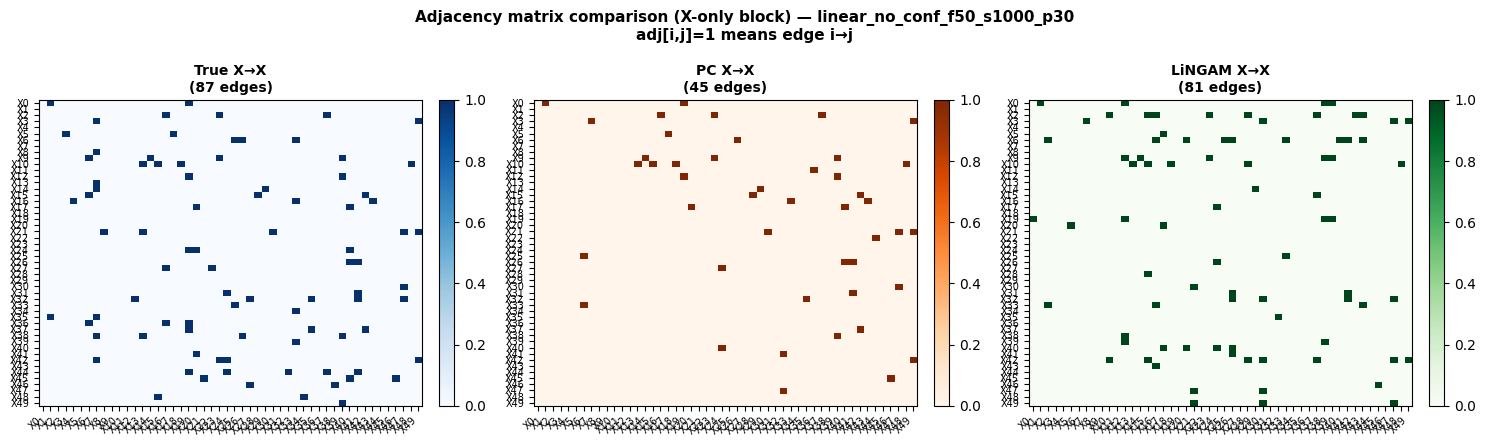

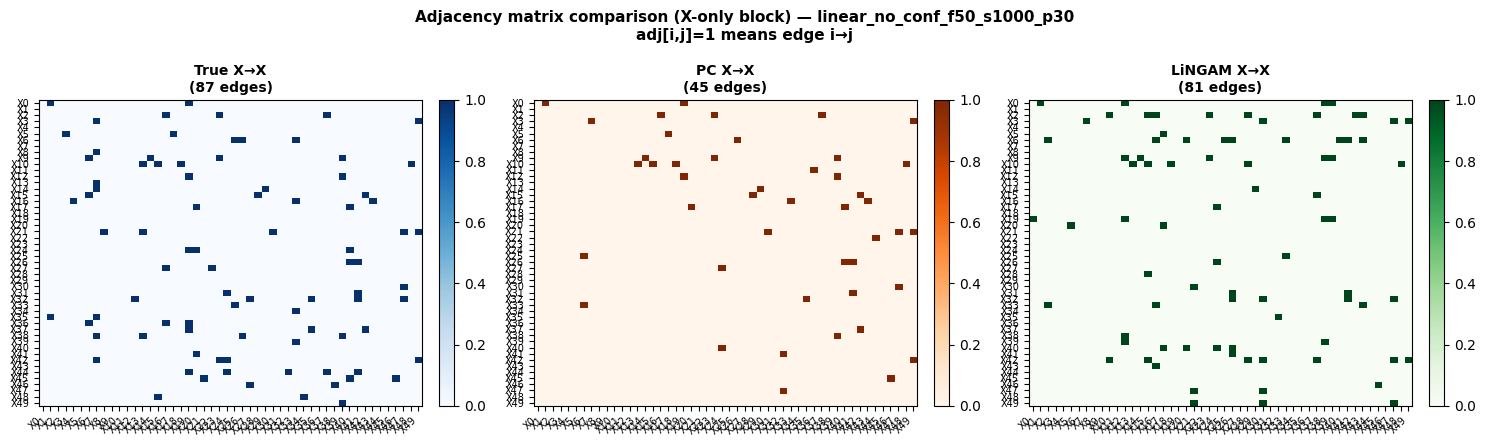

In [21]:
plot_adjacency_comparison(
    true_adj_xx, pc_train_adj_xx, lingam_train_adj_xx,
    feature_names, DATASET, save_dir=PLOTS_DIR,
)